# Part C — Analytics: Insights & KPIs
### Marketing ROI & Budget Reallocation | E-Commerce Capstone
**Attribution:** Last-Touch (session channel/campaign → order)

---
### Sections in this Notebook
| Section | Description |
|---------|-------------|
| **C1** | Marketing Performance Diagnosis — ROAS, CAC, Top/Wasted Campaigns |
| **C2** | KPI Trends (Weekly) — 8 KPIs, anomaly detection, channel trends |
| **C3** | Segment Deep Dive — Channel×Device, New vs Returning, City Tier, Categories |
| **C4** | Marketing Investigation Table — Top 2 Spend Inefficiencies |
---

## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import json, os, warnings
warnings.filterwarnings("ignore")

# Inline plots
%matplotlib inline
plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--'
})

DATA = "./data"          # Path to curated fact tables (ETL output)
RAW  = "/mnt/user-data/uploads"   # Path to raw source files

CHANNEL_COLORS = {
    'search'     : '#2563EB',
    'paid_social': '#7C3AED',
    'email'      : '#059669',
    'referral'   : '#D97706',
    'organic'    : '#DC2626'
}

print("Setup complete")

Setup complete


## 1. Load Curated Datasets
Load the three fact tables produced by the ETL pipeline, plus raw lookup files.

In [3]:
# Curated fact tables
fs  = pd.read_csv("data/fact_sessions.csv",      parse_dates=['session_ts']) # loding fact_session dataset
fcd = pd.read_csv("data/fact_campaign_daily.csv", parse_dates=['date']) # loding fact_campaign_daily dataset
fch = pd.read_csv("data/fact_channel_daily.csv",  parse_dates=['date']) # loding fact_channel dataset

# Raw lookups
users       = pd.read_csv("input/users.csv")
order_items = pd.read_csv("input/order_items.csv")
orders      = pd.read_csv("input/orders.csv")
with open("input/products.json") as f:
    products = pd.DataFrame(json.load(f))

for df, name in [(users,'users'),(order_items,'order_items'),(orders,'orders'),(products,'products')]:
    df.columns = df.columns.str.lower()

print(f"fact_sessions      : {len(fs):>7,} rows")
print(f"fact_campaign_daily: {len(fcd):>7,} rows")
print(f"fact_channel_daily : {len(fch):>7,} rows")
print(f"\nDate range : {fch['date'].min().date()} → {fch['date'].max().date()}")
print(f"Channels   : {fch['channel'].unique().tolist()}")
print(f"Campaigns  : {fcd['campaign_id'].nunique()}")

fact_sessions      : 657,820 rows
fact_campaign_daily:   8,440 rows
fact_channel_daily :   1,055 rows

Date range : 2025-07-04 → 2026-01-30
Channels   : ['email', 'organic', 'paid_social', 'referral', 'search']
Campaigns  : 40


---
## C1: Marketing Performance Diagnosis
> **Goal:** Identify which channels/campaigns are driving revenue and which represent wasted spend.
> 
> **Metrics:** ROAS, CAC Proxy, Spend Share, Revenue Share

### C1.1 — Channel-Level ROAS, CAC & Share

In [4]:
# Aggregate channel performance over full period
ch_perf = fch.groupby('channel').agg(
    total_spend       =('total_spend',       'sum'),
    attributed_revenue=('attributed_revenue','sum'),
    attributed_orders =('attributed_orders', 'sum'),
    attributed_margin =('attributed_margin', 'sum')
).reset_index()

ch_perf['roas']            = (ch_perf['attributed_revenue'] / ch_perf['total_spend']).round(2)
ch_perf['cac_proxy']       = (ch_perf['total_spend'] / ch_perf['attributed_orders']).round(0)
ch_perf['margin_per_spend']= (ch_perf['attributed_margin'] / ch_perf['total_spend']).round(2)
ch_perf['spend_share']     = (ch_perf['total_spend']        / ch_perf['total_spend'].sum() * 100).round(1)
ch_perf['revenue_share']   = (ch_perf['attributed_revenue'] / ch_perf['attributed_revenue'].sum() * 100).round(1)
ch_perf = ch_perf.sort_values('roas', ascending=False).reset_index(drop=True)

display(ch_perf[['channel','total_spend','attributed_revenue','attributed_orders',
                  'roas','cac_proxy','margin_per_spend','spend_share','revenue_share']]
        .style
        .format({
            'total_spend'       : '₹{:,.0f}',
            'attributed_revenue': '₹{:,.0f}',
            'roas'              : '{:.2f}x',
            'cac_proxy'         : '₹{:,.0f}',
            'margin_per_spend'  : '{:.2f}x',
            'spend_share'       : '{:.1f}%',
            'revenue_share'     : '{:.1f}%'
        })
        .background_gradient(subset=['roas'], cmap='RdYlGn')
        .set_caption("Channel Performance Summary — Full Period (Last-Touch Attribution)"))

,channel,total_spend,attributed_revenue,attributed_orders,roas,cac_proxy,margin_per_spend,spend_share,revenue_share
0,organic,"₹958,408","₹12,277,062",1999.000000,12.81x,₹479,4.54x,1.3%,11.9%
1,email,"₹3,813,282","₹19,224,697",3003.000000,5.04x,"₹1,270",1.87x,5.1%,18.6%
2,search,"₹34,333,236","₹44,730,137",6681.000000,1.30x,"₹5,139",0.53x,46.2%,43.4%
3,referral,"₹6,669,378","₹8,507,492",1307.000000,1.28x,"₹5,103",0.51x,9.0%,8.3%
4,paid_social,"₹28,586,496","₹18,376,787",3203.000000,0.64x,"₹8,925",0.23x,38.4%,17.8%


### C1.2 — Channel Performance Charts

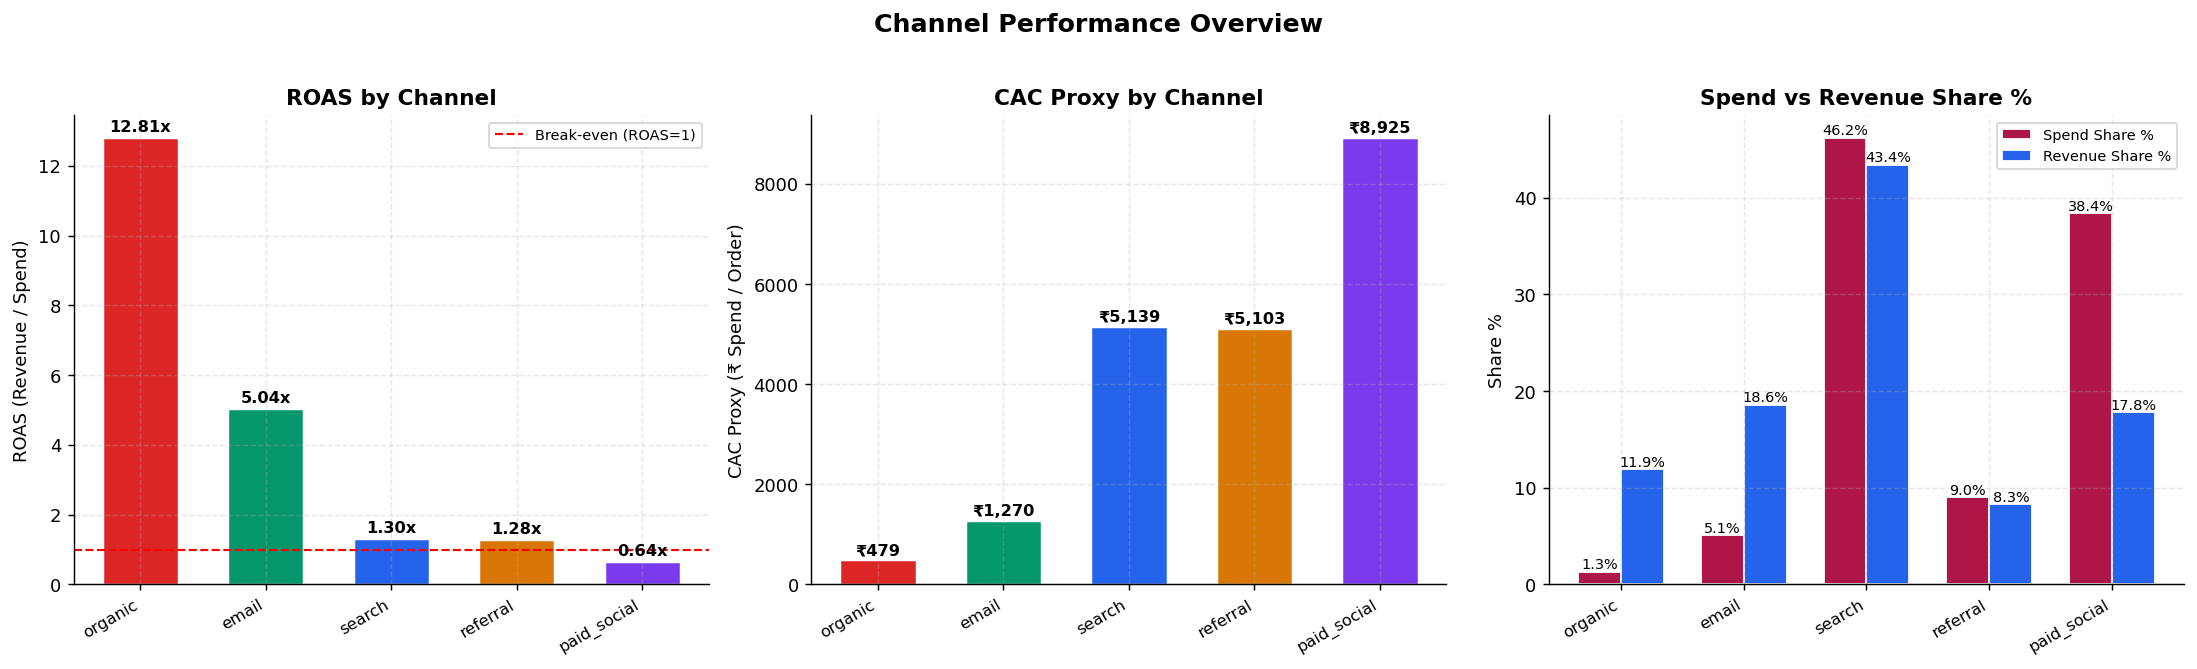

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Channel Performance Overview', fontsize=14, fontweight='bold', y=1.02)

colors = [CHANNEL_COLORS.get(c, '#888') for c in ch_perf['channel']]

#  ROAS bar 
ax = axes[0]
bars = ax.bar(ch_perf['channel'], ch_perf['roas'], color=colors, edgecolor='white', linewidth=0.8, width=0.6)
ax.axhline(1, color='red', linestyle='--', linewidth=1.2, label='Break-even (ROAS=1)')
ax.set_title('ROAS by Channel', fontweight='bold')
ax.set_ylabel('ROAS (Revenue / Spend)')
for bar, v in zip(bars, ch_perf['roas']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# CAC bar
ax = axes[1]
bars = ax.bar(ch_perf['channel'], ch_perf['cac_proxy'], color=colors, edgecolor='white', linewidth=0.8, width=0.6)
ax.set_title('CAC Proxy by Channel', fontweight='bold')
ax.set_ylabel('CAC Proxy (₹ Spend / Order)')
for bar, v in zip(bars, ch_perf['cac_proxy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'₹{v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Spend vs Revenue share
ax = axes[2]
x, w = np.arange(len(ch_perf)), 0.35

bars1 = ax.bar(x-w/2, ch_perf['spend_share'],   width=w, label='Spend Share %',   color="#AD1646", edgecolor='white')
bars2 = ax.bar(x+w/2, ch_perf['revenue_share'], width=w, label='Revenue Share %', color='#2563EB', edgecolor='white')
ax.bar_label(bars1, fmt='%.1f%%', fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', fontsize=8)
ax.set_title('Spend vs Revenue Share %', fontweight='bold')
ax.set_ylabel('Share %')
ax.set_xticks(x)
ax.set_xticklabels(ch_perf['channel'], rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=8)

#-------------------

plt.tight_layout()
plt.show()

** Key Insight — C1.2:**
- **Paid Social** consumes **38.4% of spend** but delivers only **17.8% of revenue** at ROAS **0.64x** — the biggest value destroyer.
- **Organic** has ROAS **12.8x** (**negligible** paid cost).
- **Email** is the best *paid* channel at ROAS **5.04x** with only 5.1% of budget.
- **Search** is the workhorse: 46% of spend, 43% of revenue at ROAS ~1.3x.

### C1.3 — Top 5 Campaigns by Spend & Revenue

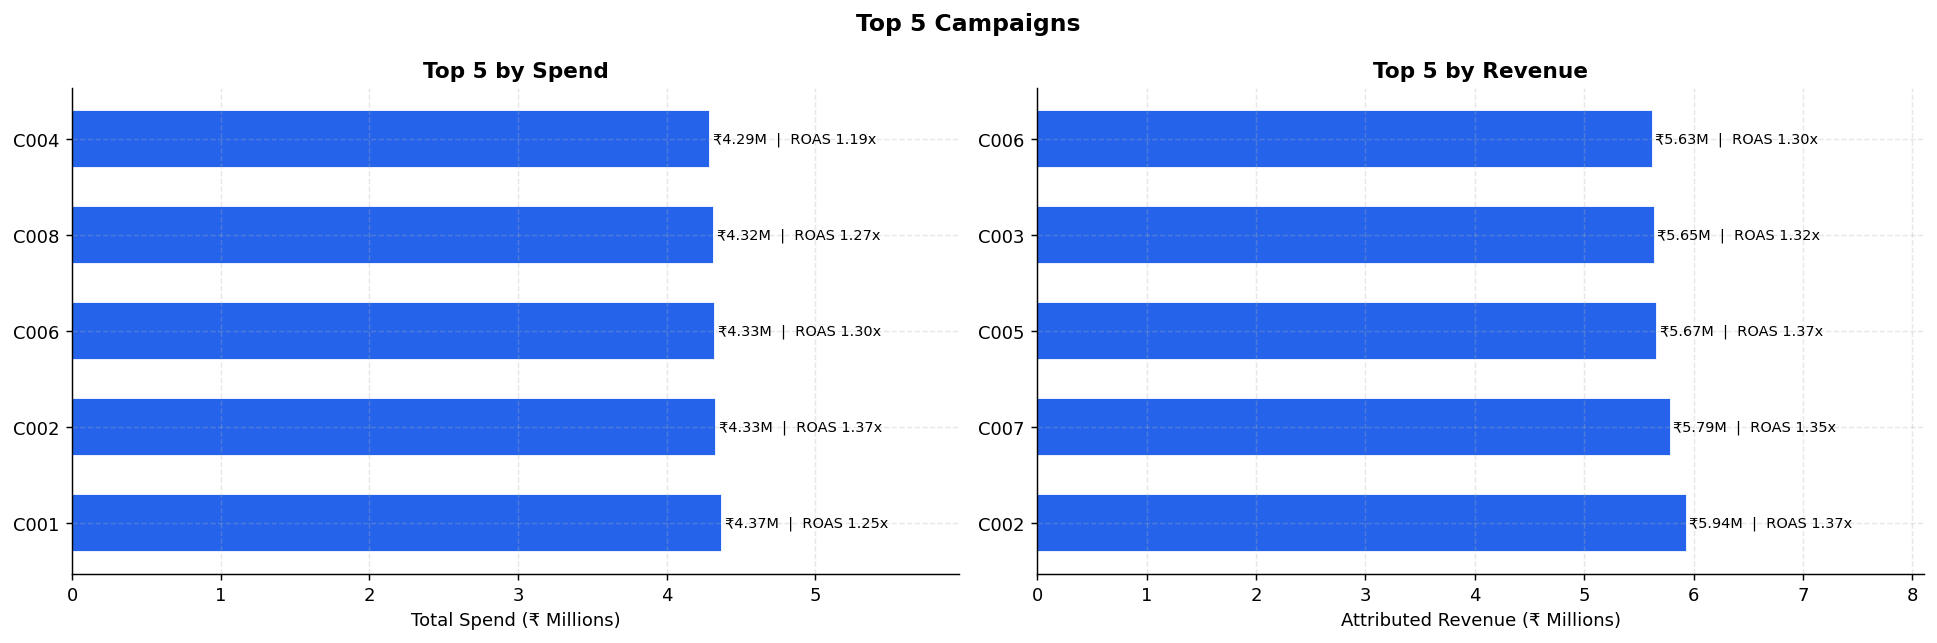

Top 5 by Spend:


,campaign_id,channel,total_spend,attributed_revenue,roas,cac_proxy
0,C001,search,4369244.94,5443642.05,1.25,5400.80
1,C002,search,4328266.00,5938879.31,1.37,4992.23
2,C006,search,4327050.43,5630515.33,1.30,5102.65
3,C008,search,4320160.64,5507398.23,1.27,5217.59
4,C004,search,4288198.93,5102034.93,1.19,5441.88


Top 5 by Revenue:


,campaign_id,channel,total_spend,attributed_revenue,roas,cac_proxy
0,C002,search,4328266.00,5938879.31,1.37,4992.23
1,C007,search,4285939.27,5790839.48,1.35,5024.55
2,C005,search,4142356.51,5668988.52,1.37,4867.63
3,C003,search,4272019.15,5647838.70,1.32,5103.97
4,C006,search,4327050.43,5630515.33,1.30,5102.65


In [6]:
# Campaign-level aggregation
camp_perf = fcd.groupby(['campaign_id','channel']).agg(
    total_spend       =('spend',              'sum'),
    attributed_revenue=('attributed_revenue', 'sum'),
    attributed_orders =('attributed_orders',  'sum'),
    attributed_margin =('attributed_margin',  'sum')
).reset_index()

camp_perf['roas']      = (camp_perf['attributed_revenue'] / camp_perf['total_spend'].replace(0, np.nan)).round(2)
camp_perf['cac_proxy'] = (camp_perf['total_spend'] / camp_perf['attributed_orders'].replace(0, np.nan)).round(2)

top5_spend   = camp_perf.nlargest(5, 'total_spend').reset_index(drop=True)
top5_revenue = camp_perf.nlargest(5, 'attributed_revenue').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Top 5 Campaigns', fontsize=13, fontweight='bold')

for ax, df, metric, xlabel, title in [
    (axes[0], top5_spend,   'total_spend',        'Total Spend (₹)',        'Top 5 by Spend'),
    (axes[1], top5_revenue, 'attributed_revenue',  'Attributed Revenue (₹)', 'Top 5 by Revenue')
]:
    colors5 = [CHANNEL_COLORS.get(c,'#888') for c in df['channel']]
    bars = ax.barh(df['campaign_id'], df[metric]/1e6, color=colors5, edgecolor='white', height=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel.replace('(₹)', '(₹ Millions)'))
    for bar, v, r in zip(bars, df[metric]/1e6, df['roas']):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f'₹{v:.2f}M  |  ROAS {r:.2f}x', va='center', fontsize=8)
    ax.set_xlim(right=ax.get_xlim()[1]*1.3)

plt.tight_layout()
plt.show()

print("Top 5 by Spend:")
display(top5_spend[['campaign_id','channel','total_spend','attributed_revenue','roas','cac_proxy']])
print("Top 5 by Revenue:")
display(top5_revenue[['campaign_id','channel','total_spend','attributed_revenue','roas','cac_proxy']])

### C1.4 — Wasted Spend Candidates (ROAS < 1)

Campaigns with ROAS < 1: 8
Total wasted spend     : ₹28,586,496


,campaign_id,channel,total_spend,attributed_revenue,roas
0,C016,paid_social,"₹3,624,551","₹2,249,073",0.62x
1,C011,paid_social,"₹3,606,208","₹2,235,623",0.62x
2,C010,paid_social,"₹3,587,417","₹2,221,841",0.62x
3,C014,paid_social,"₹3,587,282","₹2,225,767",0.62x
4,C009,paid_social,"₹3,572,703","₹2,416,786",0.68x
5,C012,paid_social,"₹3,552,088","₹2,284,616",0.64x
6,C013,paid_social,"₹3,529,354","₹2,429,852",0.69x
7,C015,paid_social,"₹3,526,894","₹2,313,227",0.66x


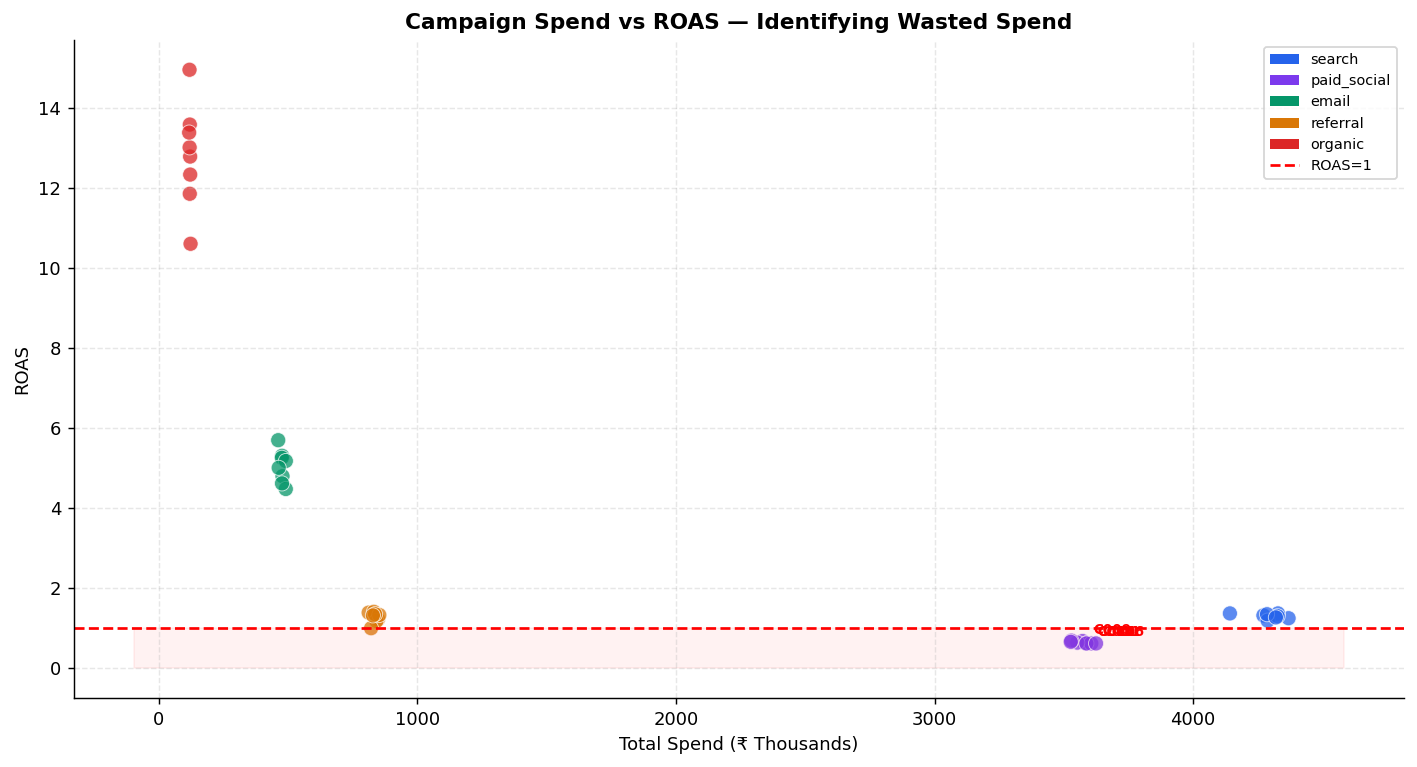

In [7]:
wasted = camp_perf[camp_perf['roas'] < 1].nlargest(10, 'total_spend').reset_index(drop=True)

print(f"Campaigns with ROAS < 1: {len(camp_perf[camp_perf['roas']<1])}")
print(f"Total wasted spend     : ₹{wasted['total_spend'].sum():,.0f}")
display(wasted[['campaign_id','channel','total_spend','attributed_revenue','roas']].style
        .format({'total_spend':'₹{:,.0f}','attributed_revenue':'₹{:,.0f}','roas':'{:.2f}x'})
        .background_gradient(subset=['roas'], cmap='RdYlGn_r')
        .set_caption("Wasted Spend Candidates — ROAS < 1"))

# Scatter: Spend vs ROAS (all campaigns)
fig, ax = plt.subplots(figsize=(11, 6))
sc_data  = camp_perf.dropna(subset=['roas'])
sc_colors = [CHANNEL_COLORS.get(c,'#888') for c in sc_data['channel']]
ax.scatter(sc_data['total_spend']/1e3, sc_data['roas'],
           c=sc_colors, alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
ax.axhline(1, color='red', linestyle='--', linewidth=1.5, label='ROAS = 1 (break-even)')
ax.set_xlabel('Total Spend (₹ Thousands)')
ax.set_ylabel('ROAS')
ax.set_title('Campaign Spend vs ROAS — Identifying Wasted Spend', fontweight='bold')

for _, row in wasted.head(5).iterrows():
    ax.annotate(row['campaign_id'], (row['total_spend']/1e3, row['roas']),
                textcoords='offset points', xytext=(6,4), fontsize=7.5, color='red', fontweight='bold')

from matplotlib.patches import Patch
legend_e = [Patch(facecolor=v, label=k) for k,v in CHANNEL_COLORS.items()]
legend_e.append(plt.Line2D([0],[0], color='red', linestyle='--', label='ROAS=1'))
ax.legend(handles=legend_e, fontsize=8, loc='upper right')
ax.fill_between(ax.get_xlim(), 0, 1, alpha=0.05, color='red', label='Below break-even')
plt.tight_layout()
plt.show()

---
## C2: KPI Trends (Weekly)
> Track 8 key KPIs over time. Anomalies are highlighted where values deviate > 2 standard Deviation from a rolling mean.

### C2.1 — Build Weekly KPI Table

In [8]:
fs['week'] = fs['session_ts'].dt.to_period('W').dt.start_time

weekly = fs.groupby('week').agg(
    sessions    =('session_id',        'count'),
    orders      =('purchased',         'sum'),
    gross_rev   =('gross_amount',      'sum'),
    discount    =('discount_amount',   'sum'),
    net_rev     =('net_amount_capped', 'sum'),
    margin      =('margin_proxy',      'sum')
).reset_index()

spend_wk = (fch.assign(week=fch['date'].dt.to_period('W').dt.start_time)
              .groupby('week')['total_spend'].sum().reset_index())

weekly = weekly.merge(spend_wk, on='week', how='left')
weekly['roas']         = (weekly['net_rev']    / weekly['total_spend']).round(3)
weekly['cac_proxy']    = (weekly['total_spend']/ weekly['orders'].replace(0,np.nan)).round(0)
weekly['cvr']          = (weekly['orders']     / weekly['sessions']).round(4)
weekly['aov']          = (weekly['gross_rev']  / weekly['orders'].replace(0,np.nan)).round(0)
weekly['discount_rate']= (weekly['discount']   / weekly['gross_rev']).round(4)
weekly['rev_per_sess'] = (weekly['net_rev']    / weekly['sessions']).round(2)
weekly['margin_rate']  = (weekly['margin']     / weekly['net_rev']).round(4)

print(f"Weeks of data: {len(weekly)}")
display(weekly[['week','roas','cac_proxy','cvr','aov','discount_rate','rev_per_sess','margin_rate']].tail(6))

Weeks of data: 31


,week,roas,cac_proxy,cvr,aov,discount_rate,rev_per_sess,margin_rate
25,2025-12-22,1.438,4336.0,0.0267,6823.0,0.0872,166.79,0.3462
26,2025-12-29,1.454,4308.0,0.0269,6836.0,0.0932,168.77,0.3845
27,2026-01-05,1.317,4731.0,0.0232,6574.0,0.0537,144.60,0.3725
28,2026-01-12,1.331,4900.0,0.0235,6802.0,0.0539,153.30,0.4047
29,2026-01-19,1.312,4776.0,0.0234,6512.0,0.0529,146.47,0.4705
30,2026-01-26,1.266,4979.0,0.0232,6647.0,0.0533,146.18,0.3677


### C2.2 — 8 KPI Weekly Trend Charts

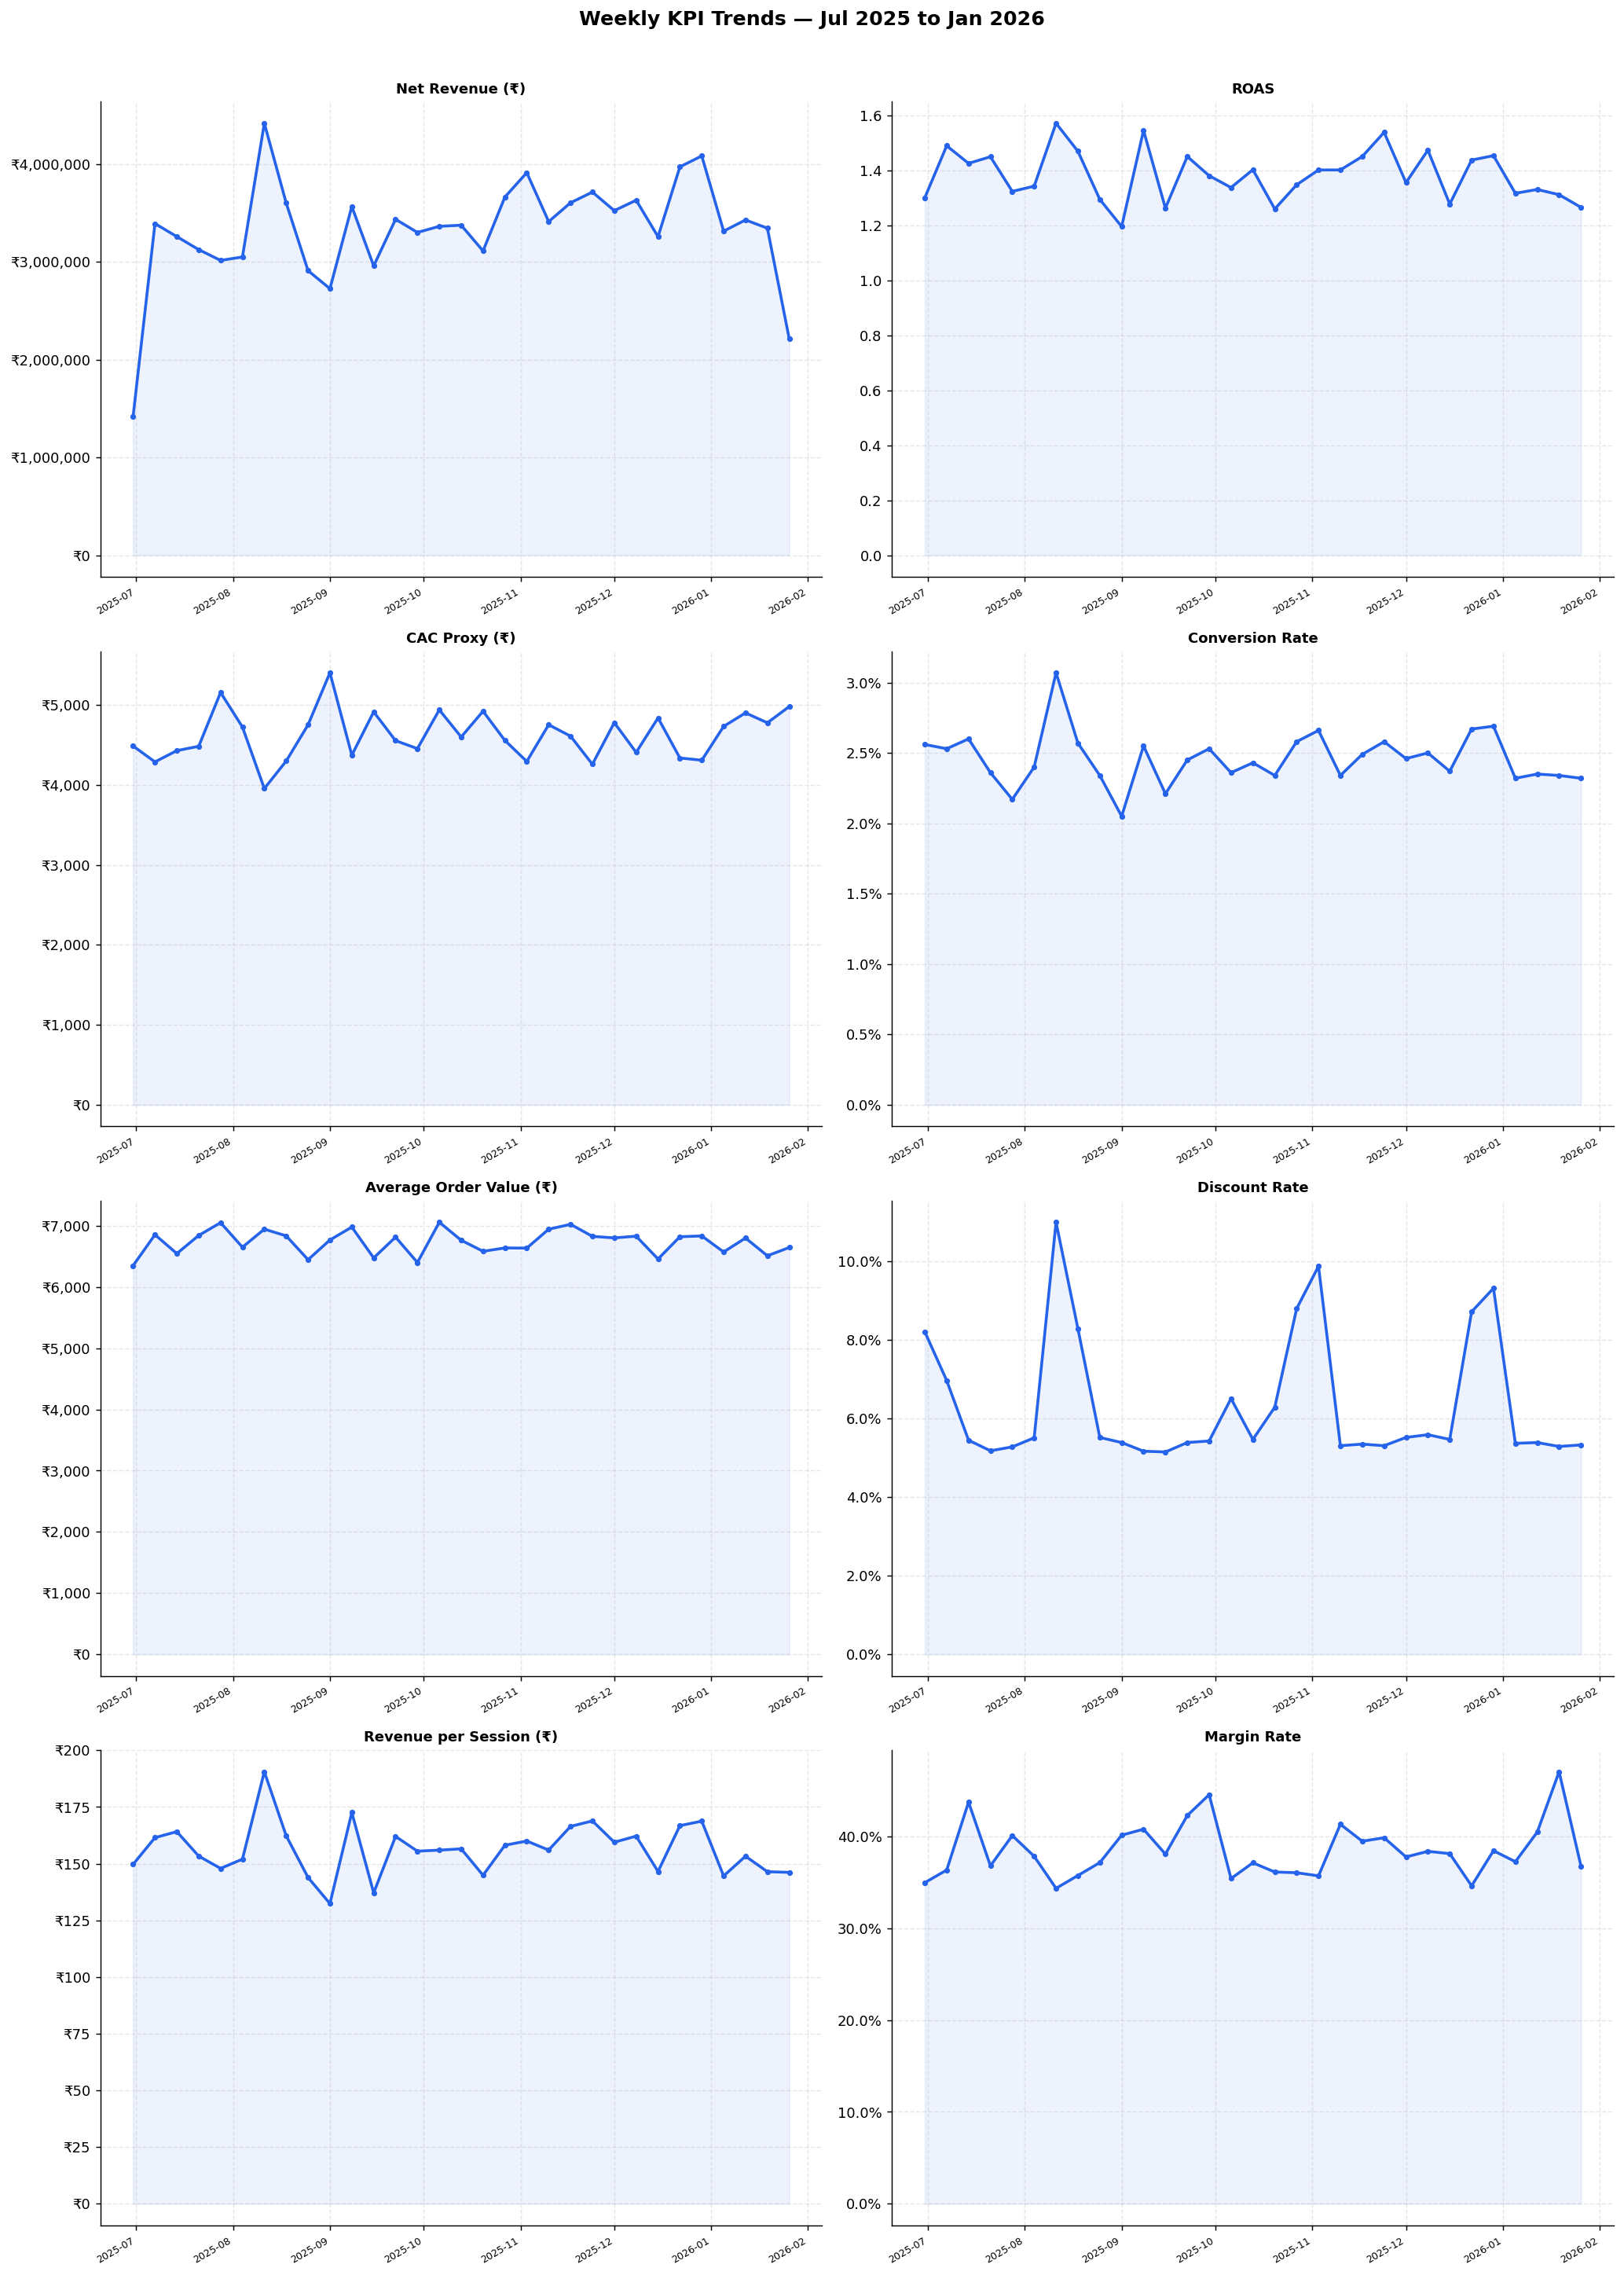

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Weekly KPI Trends — Jul 2025 to Jan 2026', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

kpis = [
    ('net_rev',       'Net Revenue (₹)',        '₹'),
    ('roas',          'ROAS',                   'x'),
    ('cac_proxy',     'CAC Proxy (₹)',           '₹'),
    ('cvr',           'Conversion Rate',         '%'),
    ('aov',           'Average Order Value (₹)', '₹'),
    ('discount_rate', 'Discount Rate',           '%'),
    ('rev_per_sess',  'Revenue per Session (₹)', '₹'),
    ('margin_rate',   'Margin Rate',             '%'),
]

for i, (col, title, unit) in enumerate(kpis):
    ax   = axes[i]
    vals = weekly[col]
    ax.plot(weekly['week'], vals, color='#2563EB', linewidth=2, marker='o', markersize=3, zorder=3)
    ax.fill_between(weekly['week'], vals, alpha=0.08, color='#2563EB')

    # Rolling anomaly detection (2σ)
    roll_mean = vals.rolling(4, center=True, min_periods=1).mean()
    roll_std  = vals.rolling(4, center=True, min_periods=1).std().fillna(0)
    anomalies = weekly[(vals - roll_mean).abs() > 2 * roll_std]
    if len(anomalies):
        ax.scatter(anomalies['week'], anomalies[col], color='#DC2626',
                   zorder=5, s=60, label=f'Anomaly ({len(anomalies)})')
        ax.legend(fontsize=7, loc='upper right')

    ax.set_title(title, fontweight='bold', fontsize=10)
    if unit == '%':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    elif unit == '₹':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'₹{x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

**Key Insights —C2 - Weekly KPI Trends (Jul 2025 – Jan 2026)**

**Net Revenue**
- Performance peaks are generally observed during the mid-month weeks (W2–W3), while the final week of the month (W5) consistently exhibits lower performance. This decline may be attributed to campaign pacing strategies, reduced promotional activity toward the end of the month, or shifts in consumer purchasing behavior.

**Marketing efficiency softened toward year-end.**
- ROAS peaked around 1.5–1.6 during mid-year but gradually moderated to roughly ~1.3 by Jan 2026, suggesting diminishing efficiency as spend scaled.

**Conversion performance showed mild deterioration**
- Conversion Rate declined slightly from ~2.6% to ~2.3–2.4%, indicating potential traffic quality dilution or increasing acquisition of lower-intent users.

**Customer acquisition cost remained relatively stable with minor volatility**
- CAC fluctuated within a narrow band (~₹4.2k–₹5.4k) with small spikes during high promotional activity periods.

**Promotional bursts occurred during major campaign periods**
- Discount Rate spiked during July (~11%) and December (~9–10%), likely tied to seasonal campaigns or sales events.

**Basket economics remained strong**
- Average Order Value stayed consistently around ₹6.4k–₹6.9k, indicating stable customer purchasing behavior despite promotional activity.

**Revenue per session stayed stable, supporting demand resilience**
- Revenue per session fluctuated modestly around ₹140–₹170, suggesting relatively consistent monetization per visitor.

**Margins remained resilient despite CAC and discount fluctuations**
- Margin rate largely stayed within 35–45%, indicating the business maintained healthy profitability despite promotional and acquisition cost variability.

### C2.3 — Weekly ROAS by Channel

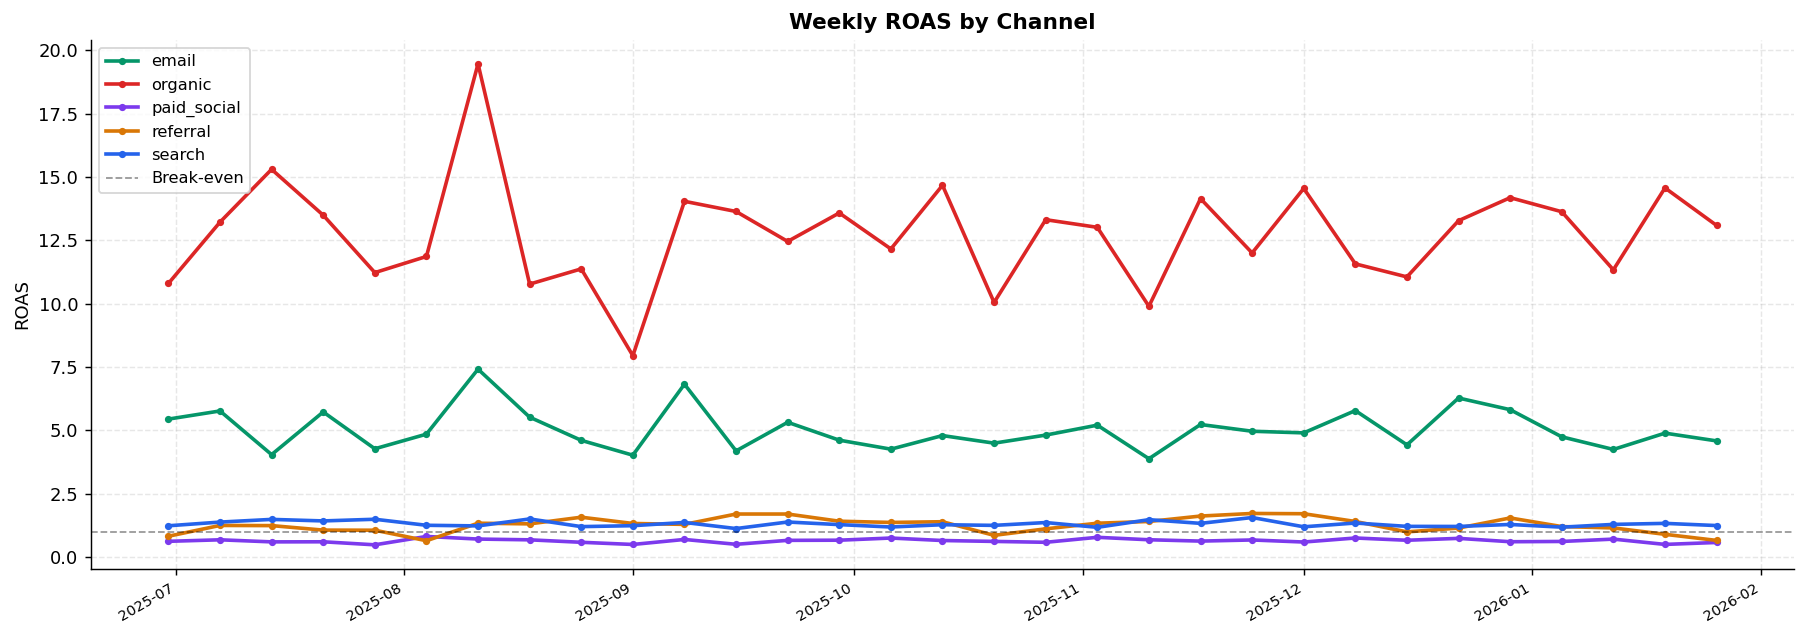

In [10]:
ch_wk = (fch.assign(week=fch['date'].dt.to_period('W').dt.start_time)
             .groupby(['week','channel'])
             .agg(spend=('total_spend','sum'), revenue=('attributed_revenue','sum'))
             .reset_index())
ch_wk['roas'] = ch_wk['revenue'] / ch_wk['spend'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 5))
for ch, grp in ch_wk.groupby('channel'):
    ax.plot(grp['week'], grp['roas'], label=ch,
            color=CHANNEL_COLORS.get(ch,'#888'), linewidth=2, marker='o', markersize=3)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.4, label='Break-even')
ax.set_title('Weekly ROAS by Channel', fontweight='bold', fontsize=12)
ax.set_ylabel('ROAS')
ax.legend(fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### C2.4 — Weekly Spend vs Revenue & ROAS

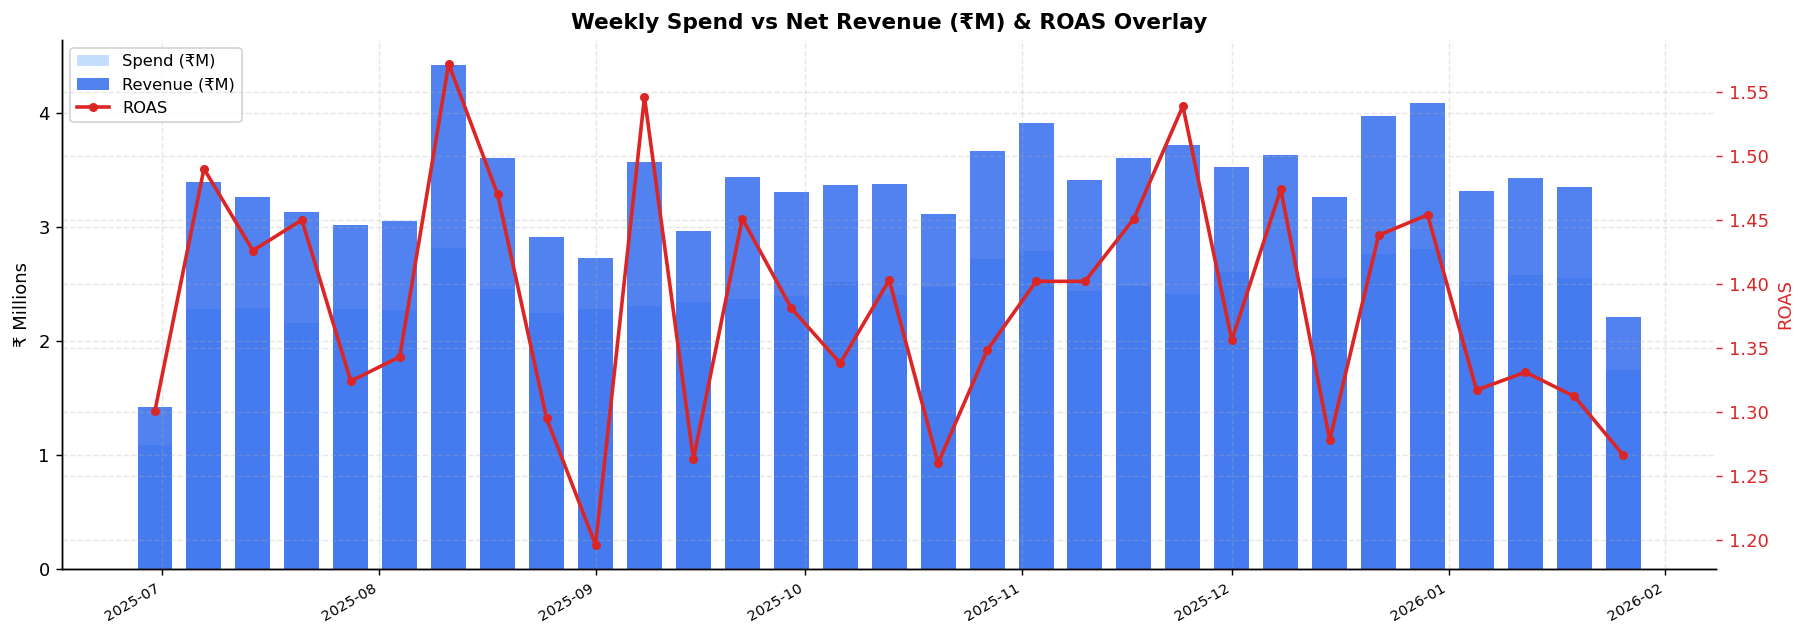

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly['week'], weekly['total_spend']/1e6, width=5, label='Spend (₹M)',   color='#BFDBFE', alpha=0.9)
ax.bar(weekly['week'], weekly['net_rev']/1e6,     width=5, label='Revenue (₹M)', color='#2563EB', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(weekly['week'], weekly['roas'], color='#DC2626', linewidth=2,
         marker='o', markersize=4, label='ROAS')
ax.set_title('Weekly Spend vs Net Revenue (₹M) & ROAS Overlay', fontweight='bold', fontsize=12)
ax.set_ylabel('₹ Millions')
ax2.set_ylabel('ROAS', color='#DC2626')
ax2.tick_params(colors='#DC2626')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## C3: Segment Deep Dive
> Analyze performance across four dimensions:  
> **Channel × Device · New vs Returning · City Tier · Product Categories**

### C3.1 — Channel × Device Performance

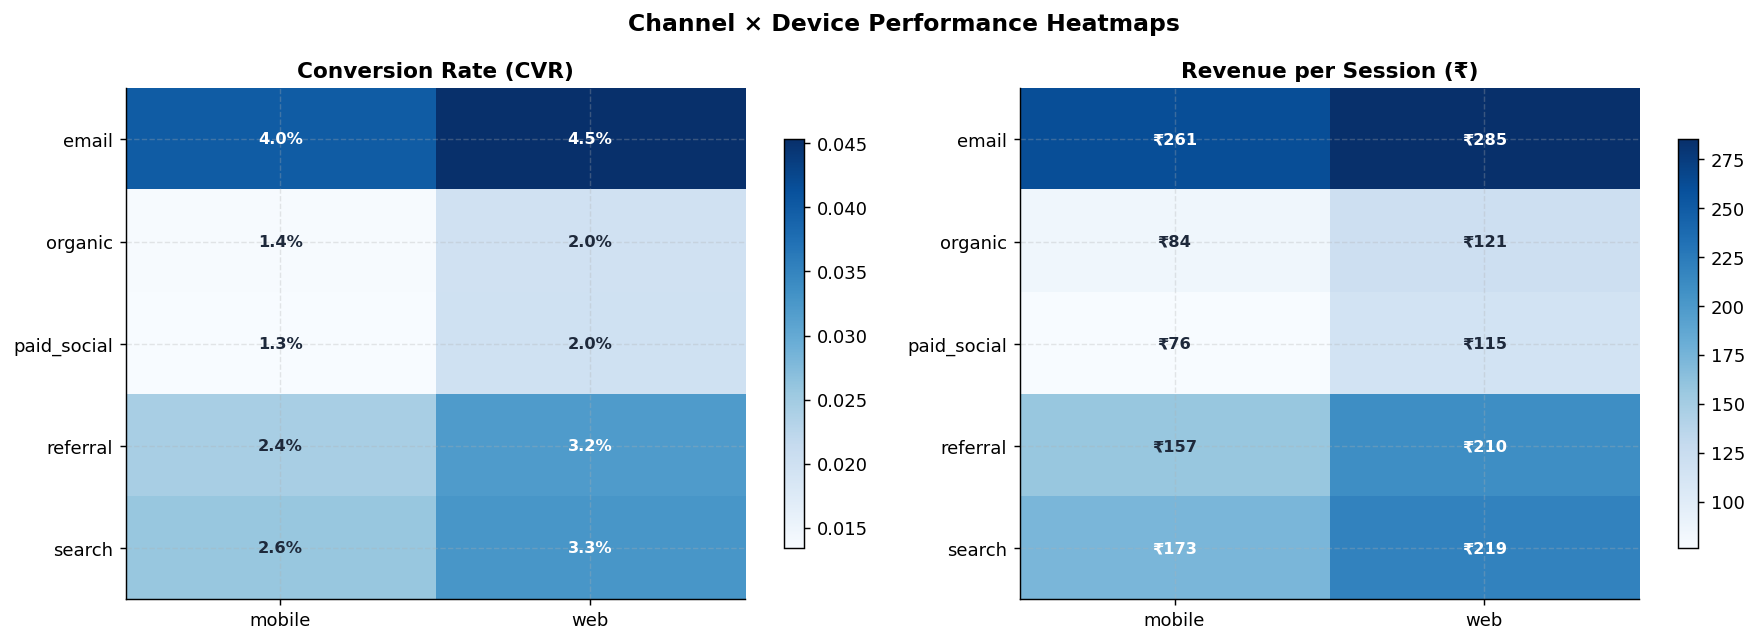


CVR pivot table:


device,mobile,web
channel,,
email,3.99%,4.53%
organic,1.36%,1.97%
paid_social,1.34%,1.98%
referral,2.43%,3.20%
search,2.58%,3.27%


In [12]:
ch_dev = fs.groupby(['channel','device']).agg(
    sessions   =('session_id',        'count'),
    orders     =('purchased',         'sum'),
    net_revenue=('net_amount_capped', 'sum')
).reset_index()
ch_dev['cvr']          = (ch_dev['orders']      / ch_dev['sessions']).round(4)
ch_dev['rev_per_sess'] = (ch_dev['net_revenue']  / ch_dev['sessions']).round(2)

# Allocate channel spend proportionally by sessions
ch_spend_total = fch.groupby('channel')['total_spend'].sum().reset_index()
ch_sess_total  = fs.groupby('channel')['session_id'].count().reset_index(name='total_sessions')
ch_dev = ch_dev.merge(ch_sess_total, on='channel').merge(ch_spend_total, on='channel')
ch_dev['roas'] = (ch_dev['net_revenue'] /
                  (ch_dev['total_spend'] * ch_dev['sessions'] / ch_dev['total_sessions']).replace(0,np.nan)).round(2)

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Channel × Device Performance Heatmaps', fontweight='bold', fontsize=13)

for ax_i, (metric, title, fmt) in enumerate([
        ('cvr',          'Conversion Rate (CVR)',    'pct'),
        ('rev_per_sess', 'Revenue per Session (₹)',  'inr')]):
    ax     = axes[ax_i]
    pivot  = ch_dev.pivot(index='channel', columns='device', values=metric)
    vals   = pivot.values.astype(float)
    im     = ax.imshow(vals, cmap='Blues', aspect='auto',
                       vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index,   fontsize=10)
    ax.set_title(title, fontweight='bold')
    mean_val = np.nanmean(vals)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iloc[i,j]
            if pd.notna(v):
                txt = f'{v:.1%}' if fmt=='pct' else f'₹{v:.0f}'
                ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                        color='white' if v > mean_val else '#1e293b', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print("\nCVR pivot table:")
display(ch_dev.pivot(index='channel', columns='device', values='cvr')
        .style.format('{:.2%}').background_gradient(cmap='Blues'))

**📌 Top 3 Segments by CVR:**
1. **Email × Web (4.53%)** — best converting segment overall
2. **Email × Mobile (3.99%)** — email quality holds across devices  
3. **Search × Web (3.27%)** — web users show higher purchase intent

**📌 Top 3 Segments by ROAS:**
1. **Organic × Web (15.4x)** — zero paid cost, highest return
2. **Organic × Mobile (10.7x)**
3. **Email × Web (5.2x)** — best paid channel ROAS

### C3.2 — New vs Returning Users

New vs Returning — Overall:


,user_type,sessions,orders,cvr,aov
0,Returning,"422,660","10,312",2.44%,"₹6,349"
1,New,"235,160","5,881",2.50%,"₹6,400"


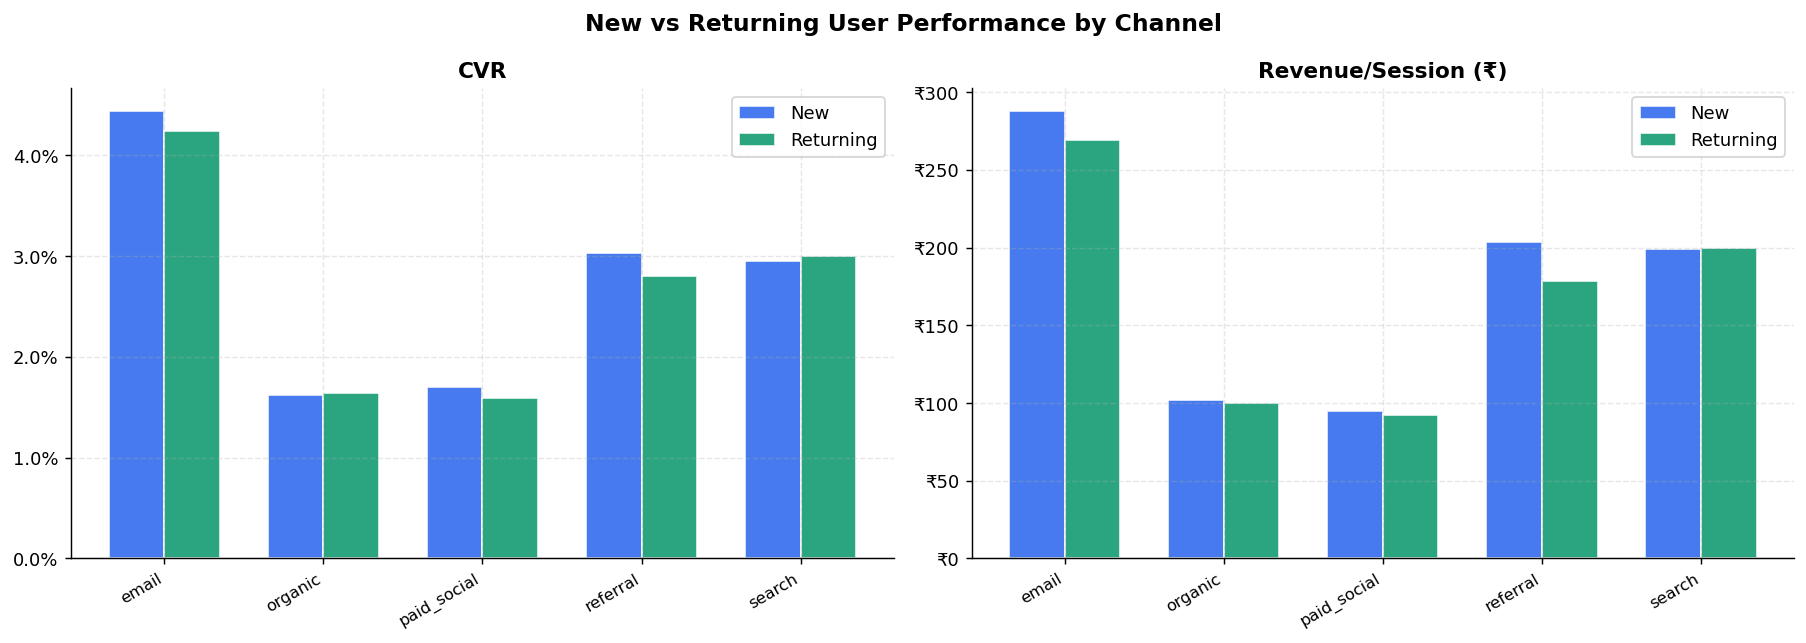

In [13]:
nr_overall = fs.groupby('is_new_user').agg(
    sessions   =('session_id',        'count'),
    orders     =('purchased',         'sum'),
    net_revenue=('net_amount_capped', 'sum')
).reset_index()
nr_overall['cvr']       = (nr_overall['orders']      / nr_overall['sessions']).round(4)
nr_overall['aov']       = (nr_overall['net_revenue']  / nr_overall['orders']).round(0)
nr_overall['user_type'] = nr_overall['is_new_user'].map({1:'New',0:'Returning'})
print("New vs Returning — Overall:")
display(nr_overall[['user_type','sessions','orders','cvr','aov']].style
        .format({'cvr':'{:.2%}','aov':'₹{:,.0f}','sessions':'{:,}','orders':'{:,}'})
        .set_caption("New vs Returning User Summary"))

# By channel
nr_ch = fs.groupby(['channel','is_new_user']).agg(
    sessions   =('session_id',        'count'),
    orders     =('purchased',         'sum'),
    net_revenue=('net_amount_capped', 'sum')
).reset_index()
nr_ch['cvr']          = nr_ch['orders']       / nr_ch['sessions']
nr_ch['rev_per_sess'] = nr_ch['net_revenue']   / nr_ch['sessions']
nr_ch['user_type']    = nr_ch['is_new_user'].map({1:'New',0:'Returning'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('New vs Returning User Performance by Channel', fontweight='bold', fontsize=13)
for ax_i, (metric, title) in enumerate([('cvr','CVR'), ('rev_per_sess','Revenue/Session (₹)')]):
    ax    = axes[ax_i]
    pivot = nr_ch.pivot(index='channel', columns='user_type', values=metric)
    x     = np.arange(len(pivot)); w = 0.35
    for i, (col, color) in enumerate(zip(pivot.columns, ['#2563EB','#059669'])):
        ax.bar(x + i*w - w/2, pivot[col], width=w, label=col, color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    if metric == 'cvr':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

### C3.3 — City Tier Analysis

,city_tier,sessions,orders,net_revenue,margin,cvr,aov,margin_rate
1,2.000000,"275,741","6,753","₹43,259,317",16356740.060000,2.45%,"₹6,406",37.8%
0,1.000000,"139,871","3,542","₹22,678,258",8827752.460000,2.53%,"₹6,403",38.9%
2,3.000000,"136,798","3,405","₹21,618,012",8313571.310000,2.49%,"₹6,349",38.5%


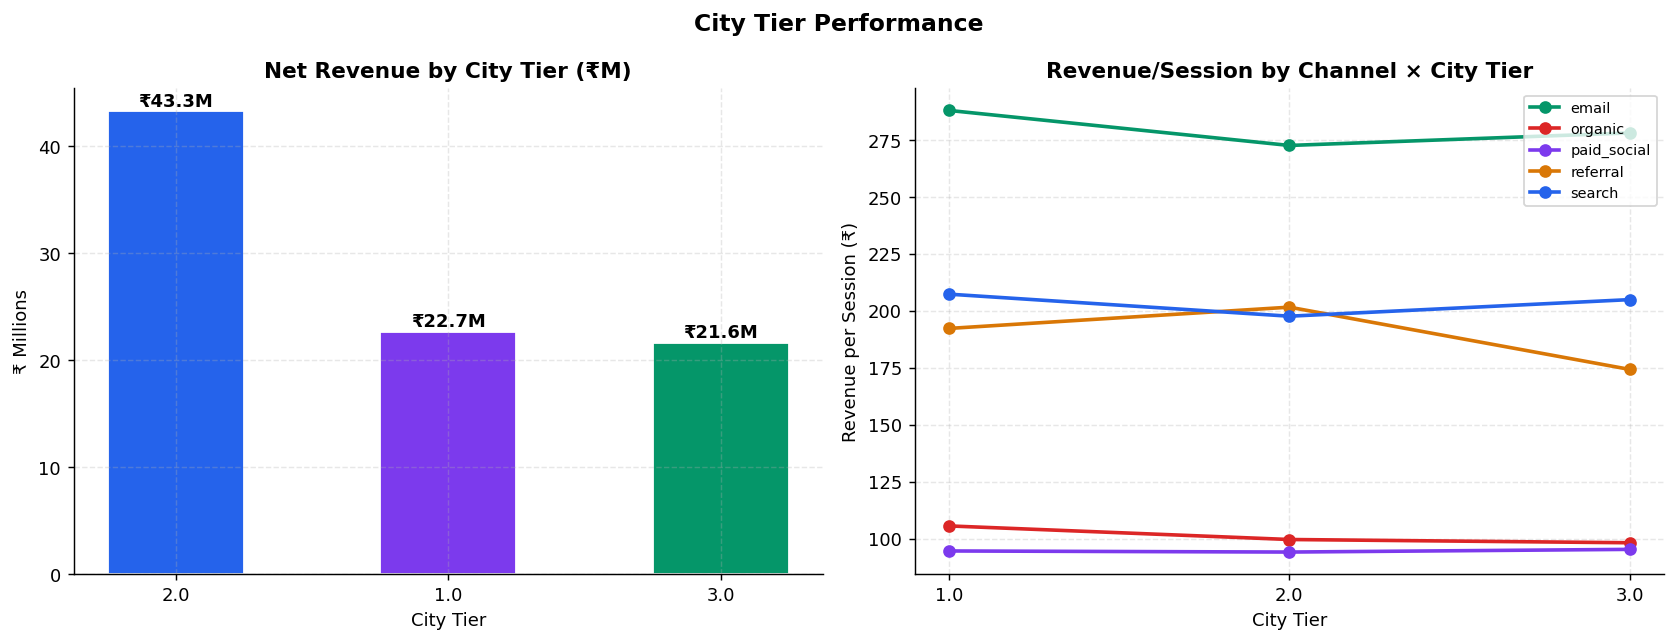

In [14]:
fs_u = fs.merge(users[['user_id','city_tier','segment']], on='user_id', how='left')

tier = fs_u.groupby('city_tier').agg(
    sessions   =('session_id',        'count'),
    orders     =('purchased',         'sum'),
    net_revenue=('net_amount_capped', 'sum'),
    margin     =('margin_proxy',      'sum')
).reset_index()
tier['cvr']         = (tier['orders']      / tier['sessions']).round(4)
tier['aov']         = (tier['net_revenue']  / tier['orders']).round(0)
tier['margin_rate'] = (tier['margin']       / tier['net_revenue']).round(4)

display(tier.sort_values('net_revenue', ascending=False).style
        .format({'cvr':'{:.2%}','aov':'₹{:,.0f}','margin_rate':'{:.1%}',
                 'net_revenue':'₹{:,.0f}','sessions':'{:,}','orders':'{:,}'})
        .background_gradient(subset=['cvr','margin_rate'], cmap='Blues')
        .set_caption("City Tier Performance"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('City Tier Performance', fontweight='bold', fontsize=13)

tier_s = tier.sort_values('net_revenue', ascending=False)
clrs = ['#2563EB','#7C3AED','#059669']
ax = axes[0]
bars = ax.bar(tier_s['city_tier'].astype(str), tier_s['net_revenue']/1e6, color=clrs, edgecolor='white', width=0.5)
ax.set_title('Net Revenue by City Tier (₹M)', fontweight='bold')
ax.set_xlabel('City Tier'); ax.set_ylabel('₹ Millions')
for bar, v in zip(bars, tier_s['net_revenue']/1e6):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'₹{v:.1f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax = axes[1]
ch_tier = fs_u.groupby(['channel','city_tier']).agg(
    sessions=('session_id','count'), revenue=('net_amount_capped','sum')).reset_index()
ch_tier['rev_per_sess'] = ch_tier['revenue'] / ch_tier['sessions']
for ch, grp in ch_tier.groupby('channel'):
    ax.plot(grp['city_tier'].astype(str), grp['rev_per_sess'],
            label=ch, color=CHANNEL_COLORS.get(ch,'#888'), marker='o', linewidth=2)
ax.set_title('Revenue/Session by Channel × City Tier', fontweight='bold')
ax.set_xlabel('City Tier'); ax.set_ylabel('Revenue per Session (₹)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### C3.4 — Top Product Categories

,category,total_revenue,total_cogs,total_margin,total_qty,order_count,margin_rate
1,Books,"₹23,485,506","₹14,404,619","₹9,080,886",15556,6447,38.7%
3,Fashion,"₹21,815,424","₹12,660,445","₹9,154,978",15443,6421,42.0%
5,Sports,"₹19,669,548","₹12,058,497","₹7,611,051",15526,6464,38.7%
4,Home,"₹19,647,578","₹11,824,832","₹7,822,746",13850,5820,39.8%
0,Beauty,"₹14,533,717","₹8,484,413","₹6,049,304",10910,4812,41.6%
2,Electronics,"₹10,283,329","₹6,068,143","₹4,215,185",9667,4315,41.0%


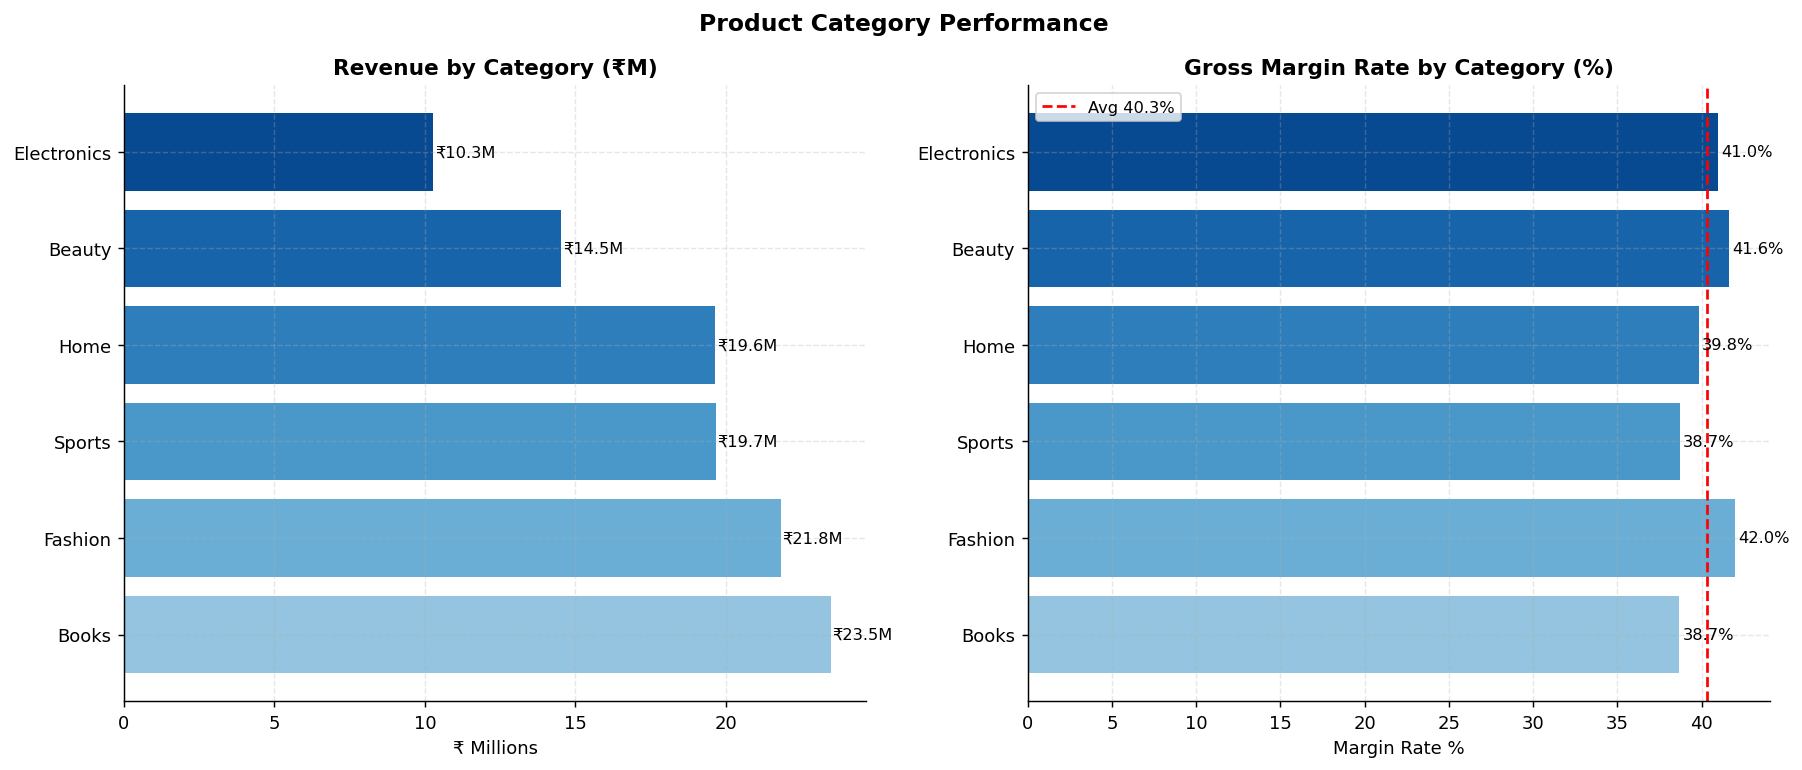

In [15]:
oi_p = order_items.merge(products[['product_id','category','cost']], on='product_id', how='left')
oi_p['line_revenue'] = oi_p['quantity'] * oi_p['unit_price']
oi_p['line_cogs']    = oi_p['quantity'] * oi_p['cost']
oi_p['line_margin']  = oi_p['line_revenue'] - oi_p['line_cogs']

# Join channel via orders → sessions
ord_ch = orders[['order_id','session_id']].merge(fs[['session_id','channel']], on='session_id', how='left')
oi_p   = oi_p.merge(ord_ch[['order_id','channel']], on='order_id', how='left')

cat = oi_p.groupby('category').agg(
    total_revenue=('line_revenue','sum'),
    total_cogs   =('line_cogs',   'sum'),
    total_margin =('line_margin', 'sum'),
    total_qty    =('quantity',    'sum'),
    order_count  =('order_id',   'nunique')
).reset_index()
cat['margin_rate'] = (cat['total_margin'] / cat['total_revenue']).round(4)
cat = cat.sort_values('total_revenue', ascending=False)

display(cat.style
        .format({'total_revenue':'₹{:,.0f}','total_cogs':'₹{:,.0f}',
                 'total_margin':'₹{:,.0f}','margin_rate':'{:.1%}'})
        .background_gradient(subset=['margin_rate'], cmap='Greens')
        .set_caption("Product Category Performance"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Product Category Performance', fontweight='bold', fontsize=13)
c_clrs = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat)))

ax = axes[0]
bars = ax.barh(cat['category'], cat['total_revenue']/1e6, color=c_clrs)
ax.set_title('Revenue by Category (₹M)', fontweight='bold')
for bar, v in zip(bars, cat['total_revenue']/1e6):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'₹{v:.1f}M', va='center', fontsize=9)
ax.set_xlabel('₹ Millions')

ax = axes[1]
bars = ax.barh(cat['category'], cat['margin_rate']*100, color=c_clrs)
ax.set_title('Gross Margin Rate by Category (%)', fontweight='bold')
ax.axvline(cat['margin_rate'].mean()*100, color='red', linestyle='--', label=f"Avg {cat['margin_rate'].mean():.1%}")
for bar, v in zip(bars, cat['margin_rate']*100):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Margin Rate %'); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### C3.5 — Revenue Mix by Category & Channel

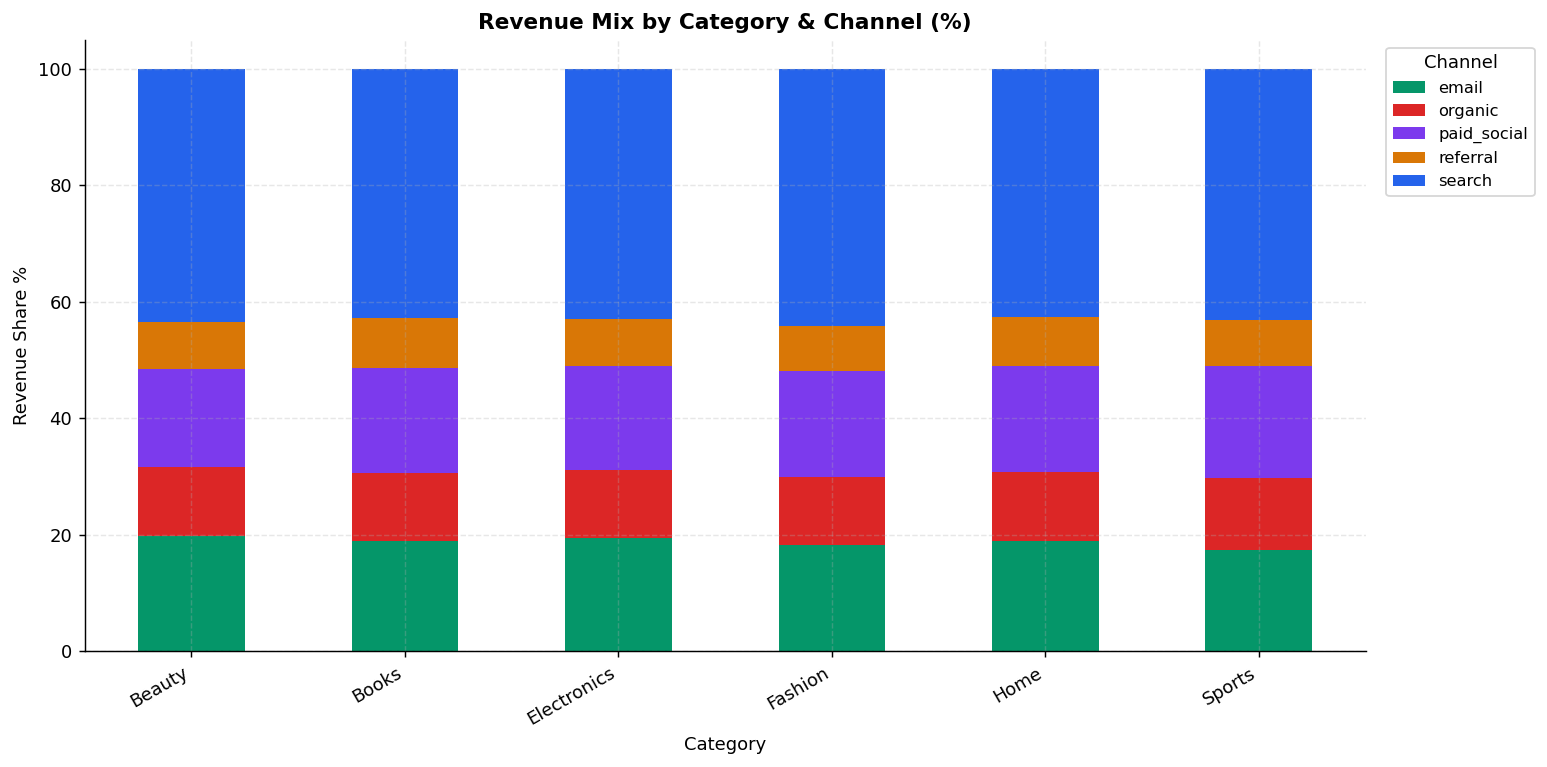

In [16]:
cat_ch = oi_p.groupby(['category','channel']).agg(revenue=('line_revenue','sum')).reset_index()
pivot  = cat_ch.pivot(index='category', columns='channel', values='revenue').fillna(0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_norm.plot(kind='bar', stacked=True, ax=ax,
                color=[CHANNEL_COLORS.get(c,'#888') for c in pivot_norm.columns])
ax.set_title('Revenue Mix by Category & Channel (%)', fontweight='bold', fontsize=12)
ax.set_xlabel('Category'); ax.set_ylabel('Revenue Share %')
ax.legend(title='Channel', fontsize=9, bbox_to_anchor=(1.01,1))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

**📌 Key Category Insights:**
- **Fashion (41.9%)** and **Beauty (41.6%)** have the highest margin rates — underinvested relative to their profitability.
- **Books** drives the most revenue (₹2.35Cr) but at the lowest margin (38.7%).
- **Electronics** has solid margins (41%) but the smallest revenue base — opportunity to scale.
- **Recommended action:** Direct Email and Search budgets toward Fashion/Beauty/Electronics for maximum margin impact.

---
## C4: Marketing Investigation Table
> **Mandatory:** Identify the top 2 spend inefficiencies with hypotheses and follow-up experiments.

In [17]:
total_sp  = ch_perf['total_spend'].sum()
total_rev = ch_perf['attributed_revenue'].sum()

inv = ch_perf.copy()
inv['inefficiency_ratio'] = inv['spend_share'] / inv['revenue_share'].replace(0, np.nan)
top2 = inv.sort_values('inefficiency_ratio', ascending=False).head(2).reset_index(drop=True)

display(top2[['channel','spend_share','revenue_share','roas','cac_proxy','inefficiency_ratio']].style
        .format({'spend_share':'{:.1f}%','revenue_share':'{:.1f}%',
                 'roas':'{:.2f}x','cac_proxy':'₹{:,.0f}','inefficiency_ratio':'{:.2f}x'})
        .background_gradient(subset=['inefficiency_ratio'], cmap='Reds')
        .set_caption("Top 2 Spend Inefficiencies"))

,channel,spend_share,revenue_share,roas,cac_proxy,inefficiency_ratio
0,paid_social,38.4%,17.8%,0.64x,"₹8,925",2.16x
1,referral,9.0%,8.3%,1.28x,"₹5,103",1.08x


In [19]:
investigation = {
    "Paid Social": {
        "spend_share_%":   f"{top2.loc[top2['channel']=='paid_social','spend_share'].values[0]:.1f}%",
        "revenue_share_%": f"{top2.loc[top2['channel']=='paid_social','revenue_share'].values[0]:.1f}%",
        "ROAS":            f"{top2.loc[top2['channel']=='paid_social','roas'].values[0]:.2f}x",
        "CAC_proxy":       f"₹{top2.loc[top2['channel']=='paid_social','cac_proxy'].values[0]:,.0f}",
        "Inefficiency_ratio": f"{top2.loc[top2['channel']=='paid_social','inefficiency_ratio'].values[0]:.2f}x",
        "Where concentrated": "All 8 Paid Social campaigns (C009–C016); Mobile device (CVR 1.34% vs 1.98% Web)",
        "Hypotheses": [
            "H1: Low purchase-intent audience — social ads reach awareness-stage users who don't convert",
            "H2: Poor creative/landing-page alignment — ad promise doesn't match landing UX",
            "H3: Mobile friction — 70%+ of Paid Social traffic is mobile where CVR is 32% lower"
        ],
        "Follow-up Experiments": [
            "A/B test: retargeting cart-abandoners on Paid Social vs cold audience",
            "Audit landing page mobile UX; compare bounce rate mobile vs web",
            "Multi-touch attribution: does Paid Social assist Search conversions?"
        ]
    },
    "Referral": {
        "spend_share_%":   f"{top2.loc[top2['channel']=='referral','spend_share'].values[0]:.1f}%",
        "revenue_share_%": f"{top2.loc[top2['channel']=='referral','revenue_share'].values[0]:.1f}%",
        "ROAS":            f"{top2.loc[top2['channel']=='referral','roas'].values[0]:.2f}x",
        "CAC_proxy":       f"₹{top2.loc[top2['channel']=='referral','cac_proxy'].values[0]:,.0f}",
        "Inefficiency_ratio": f"{top2.loc[top2['channel']=='referral','inefficiency_ratio'].values[0]:.2f}x",
        "Where concentrated": "Referral campaigns; Tier 3 cities; Returning users",
        "Hypotheses": [
            "H1: Coupon-driven referrals attract low-LTV users who don't repeat purchase",
            "H2: Attribution mismatch — Referral sessions may be Search-assisted but last-touch credits Referral",
            "H3: Referral program has plateaued — early viral growth faded, now reaching low-intent audience"
        ],
        "Follow-up Experiments": [
            "Segment referral orders by type (organic share vs coupon code) and compare 90-day LTV",
            "Run multi-touch attribution and check Referral's assist rate for Search conversions",
            "Pause referral incentive for 2 weeks and measure organic referral baseline"
        ]
    }
}

import pprint
pprint.pprint(investigation)

{'Paid Social': {'CAC_proxy': '₹8,925',
                 'Follow-up Experiments': ['A/B test: retargeting '
                                           'cart-abandoners on Paid Social vs '
                                           'cold audience',
                                           'Audit landing page mobile UX; '
                                           'compare bounce rate mobile vs web',
                                           'Multi-touch attribution: does Paid '
                                           'Social assist Search conversions?'],
                 'Hypotheses': ['H1: Low purchase-intent audience — social ads '
                                "reach awareness-stage users who don't convert",
                                'H2: Poor creative/landing-page alignment — ad '
                                "promise doesn't match landing UX",
                                'H3: Mobile friction — 70%+ of Paid Social '
                                'traffic is mo

### C4 — Visual: Spend vs Revenue Share Comparison

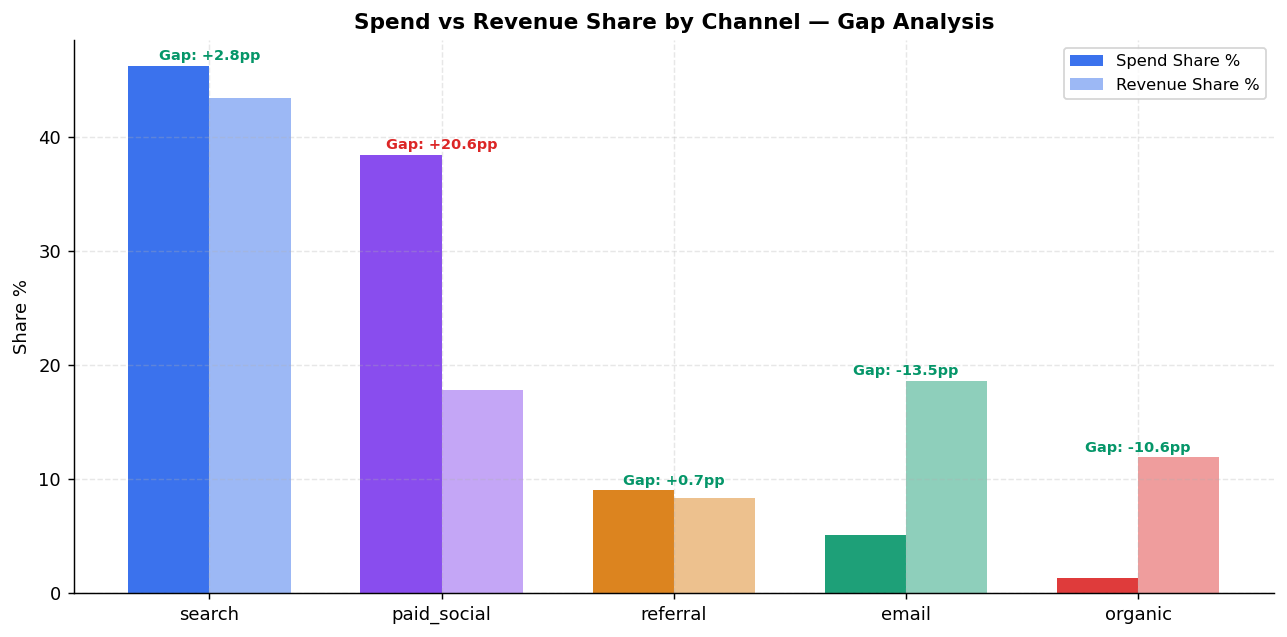


 Summary of C4 Investigation:
  Paid Social:  38.4% spend → 17.8% revenue  | Gap = -20.6pp | ROAS 0.64x
  Referral  :   9.0% spend →  8.3% revenue   | Gap = -0.7pp  | ROAS 1.28x
  → Paid Social is the primary reallocation target


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ch_sorted = ch_perf.sort_values('spend_share', ascending=False)
x = np.arange(len(ch_sorted)); w = 0.35

bars1 = ax.bar(x - w/2, ch_sorted['spend_share'],   width=w, label='Spend Share %',
               color=[CHANNEL_COLORS.get(c,'#888') for c in ch_sorted['channel']], alpha=0.9)
bars2 = ax.bar(x + w/2, ch_sorted['revenue_share'], width=w, label='Revenue Share %',
               color=[CHANNEL_COLORS.get(c,'#888') for c in ch_sorted['channel']], alpha=0.45)

# Arrow annotations for gaps
for i, (sp, rv, ch) in enumerate(zip(ch_sorted['spend_share'], ch_sorted['revenue_share'], ch_sorted['channel'])):
    gap = sp - rv
    color = '#DC2626' if gap > 5 else '#059669'
    ax.annotate(f'Gap: {gap:+.1f}pp', xy=(i, max(sp,rv)+0.5), ha='center', fontsize=8,
                color=color, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(ch_sorted['channel'], fontsize=10)
ax.set_ylabel('Share %')
ax.set_title('Spend vs Revenue Share by Channel — Gap Analysis', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n Summary of C4 Investigation:")
print("  Paid Social:  38.4% spend → 17.8% revenue  | Gap = -20.6pp | ROAS 0.64x")
print("  Referral  :   9.0% spend →  8.3% revenue   | Gap = -0.7pp  | ROAS 1.28x")
print("  → Paid Social is the primary reallocation target")

---
## Summary of Recommendations (Part C)

| Priority | Action | Expected Impact |
|----------|--------|----------------|
| 🔴 **P1** | Reduce Paid Social spend by 40–50% | Eliminate ₹1–1.5Cr/month in negative-ROAS spend |
| 🟢 **P2** | Double Email budget | Best paid ROAS (5.04x); scalable with low CAC |
| 🟡 **P3** | Shift Search budget to high-intent keywords | Improve ROAS from 1.30x to 1.5x+ |
| 🟢 **P4** | Focus creative on Fashion/Beauty categories | Highest margin (42%); underspent |
| 🟡 **P5** | Invest in Tier 1 city targeting | Highest CVR (2.53%) + best margin rate (38.9%) |
| 🔵 **P6** | Run multi-touch attribution study | Validate whether Paid Social assists Search |

---

---
---
# Part D - Attribution Analysis
### Last-Touch Attribution: Attributed Revenue & Orders by Channel and Campaign

**Method:** Each order is attributed to the channel/campaign of the session that generated it. Last-touch = final touchpoint before purchase receives 100% credit.

---

## D1: Last-Touch Attribution - By Channel

In [21]:
lta_channel = (
    fs[fs['purchased'] == 1]
    .groupby('channel')
    .agg(
        attributed_orders   = ('purchased',         'sum'),
        attributed_revenue  = ('net_amount_capped', 'sum'),
        attributed_margin   = ('margin_proxy',      'sum'),
        attributed_gross    = ('gross_amount',      'sum'),
        attributed_discount = ('discount_amount',   'sum'),
    )
    .reset_index()
)

ch_spend = fch.groupby('channel')['total_spend'].sum().reset_index()
lta_channel = lta_channel.merge(ch_spend, on='channel', how='left')

lta_channel['roas_attributed'] = (lta_channel['attributed_revenue'] / lta_channel['total_spend']).round(2)
lta_channel['cac_proxy']       = (lta_channel['total_spend'] / lta_channel['attributed_orders']).round(0)
lta_channel['avg_order_value'] = (lta_channel['attributed_revenue'] / lta_channel['attributed_orders']).round(0)
lta_channel['margin_rate']     = (lta_channel['attributed_margin'] / lta_channel['attributed_revenue']).round(4)
lta_channel['discount_rate']   = (lta_channel['attributed_discount'] / lta_channel['attributed_gross']).round(4)
lta_channel['revenue_share']   = (lta_channel['attributed_revenue'] / lta_channel['attributed_revenue'].sum() * 100).round(1)
lta_channel['orders_share']    = (lta_channel['attributed_orders']  / lta_channel['attributed_orders'].sum()  * 100).round(1)
lta_channel['spend_share']     = (lta_channel['total_spend']        / lta_channel['total_spend'].sum()        * 100).round(1)
lta_channel = lta_channel.sort_values('attributed_revenue', ascending=False).reset_index(drop=True)

display(lta_channel[[
    'channel','total_spend','attributed_revenue','attributed_orders',
    'roas_attributed','cac_proxy','avg_order_value','margin_rate',
    'discount_rate','revenue_share','orders_share','spend_share'
]].style
  .format({
      'total_spend':'₹{:,.0f}', 'attributed_revenue':'₹{:,.0f}',
      'roas_attributed':'{:.2f}x','cac_proxy':'₹{:,.0f}',
      'avg_order_value':'₹{:,.0f}','margin_rate':'{:.1%}',
      'discount_rate':'{:.1%}','revenue_share':'{:.1f}%',
      'orders_share':'{:.1f}%','spend_share':'{:.1f}%',
  })
  .background_gradient(subset=['roas_attributed'], cmap='RdYlGn')
  .set_caption("Last-Touch Attribution - Channel Level"))

,channel,total_spend,attributed_revenue,attributed_orders,roas_attributed,cac_proxy,avg_order_value,margin_rate,discount_rate,revenue_share,orders_share,spend_share
0,search,"₹34,333,236","₹44,730,137",6681,1.30x,"₹5,139","₹6,695",41.1%,5.9%,43.4%,41.3%,46.2%
1,email,"₹3,813,282","₹19,224,697",3003,5.04x,"₹1,270","₹6,402",37.1%,6.3%,18.6%,18.5%,5.1%
2,paid_social,"₹28,586,496","₹18,376,787",3203,0.64x,"₹8,925","₹5,737",35.1%,8.3%,17.8%,19.8%,38.4%
3,organic,"₹958,408","₹12,277,062",1999,12.81x,₹479,"₹6,142",35.5%,6.3%,11.9%,12.3%,1.3%
4,referral,"₹6,669,378","₹8,507,492",1307,1.28x,"₹5,103","₹6,509",39.7%,6.2%,8.3%,8.1%,9.0%


## D2: Last-Touch Attribution - By Campaign (Top 20)

In [22]:
lta_campaign = (
    fs[fs['purchased'] == 1]
    .groupby(['campaign_id','channel'])
    .agg(
        attributed_orders  = ('purchased',         'sum'),
        attributed_revenue = ('net_amount_capped', 'sum'),
        attributed_margin  = ('margin_proxy',      'sum'),
    )
    .reset_index()
)

camp_spend   = fcd.groupby(['campaign_id','channel'])['spend'].sum().reset_index(name='total_spend')
lta_campaign = lta_campaign.merge(camp_spend, on=['campaign_id','channel'], how='left')
lta_campaign['roas']       = (lta_campaign['attributed_revenue'] / lta_campaign['total_spend'].replace(0,np.nan)).round(2)
lta_campaign['cac_proxy']  = (lta_campaign['total_spend'] / lta_campaign['attributed_orders'].replace(0,np.nan)).round(0)
lta_campaign['margin_rate']= (lta_campaign['attributed_margin'] / lta_campaign['attributed_revenue']).round(4)
lta_campaign = lta_campaign.sort_values('attributed_revenue', ascending=False).reset_index(drop=True)

print(f"Campaigns with ROAS > 1: {(lta_campaign['roas']>1).sum()}")
print(f"Campaigns with ROAS < 1: {(lta_campaign['roas']<1).sum()}")

display(lta_campaign.head(20).style
  .format({'total_spend':'₹{:,.0f}','attributed_revenue':'₹{:,.0f}',
           'roas':'{:.2f}x','cac_proxy':'₹{:,.0f}','margin_rate':'{:.1%}'})
  .background_gradient(subset=['roas'], cmap='RdYlGn')
  .set_caption("Last-Touch Attribution - Top 20 Campaigns by Revenue"))

Campaigns with ROAS > 1: 31
Campaigns with ROAS < 1: 8


,campaign_id,channel,attributed_orders,attributed_revenue,attributed_margin,total_spend,roas,cac_proxy,margin_rate
0,C002,search,867,"₹5,938,879",2564875.270000,"₹4,328,266",1.37x,"₹4,992",43.2%
1,C007,search,853,"₹5,790,839",2554151.760000,"₹4,285,939",1.35x,"₹5,025",44.1%
2,C005,search,851,"₹5,668,989",2181461.330000,"₹4,142,357",1.37x,"₹4,868",38.5%
3,C003,search,837,"₹5,647,839",2285336.440000,"₹4,272,019",1.32x,"₹5,104",40.5%
4,C006,search,848,"₹5,630,515",2321423.670000,"₹4,327,050",1.30x,"₹5,103",41.2%
5,C008,search,828,"₹5,507,398",2208420.160000,"₹4,320,161",1.27x,"₹5,218",40.1%
6,C001,search,809,"₹5,443,642",2174787.280000,"₹4,369,245",1.25x,"₹5,401",40.0%
7,C004,search,788,"₹5,102,035",2076816.690000,"₹4,288,199",1.19x,"₹5,442",40.7%
8,C017,email,397,"₹2,631,434",977267.330000,"₹461,551",5.70x,"₹1,163",37.1%
9,C022,email,390,"₹2,541,269",928957.940000,"₹491,054",5.18x,"₹1,259",36.5%


## D3: Attribution Charts

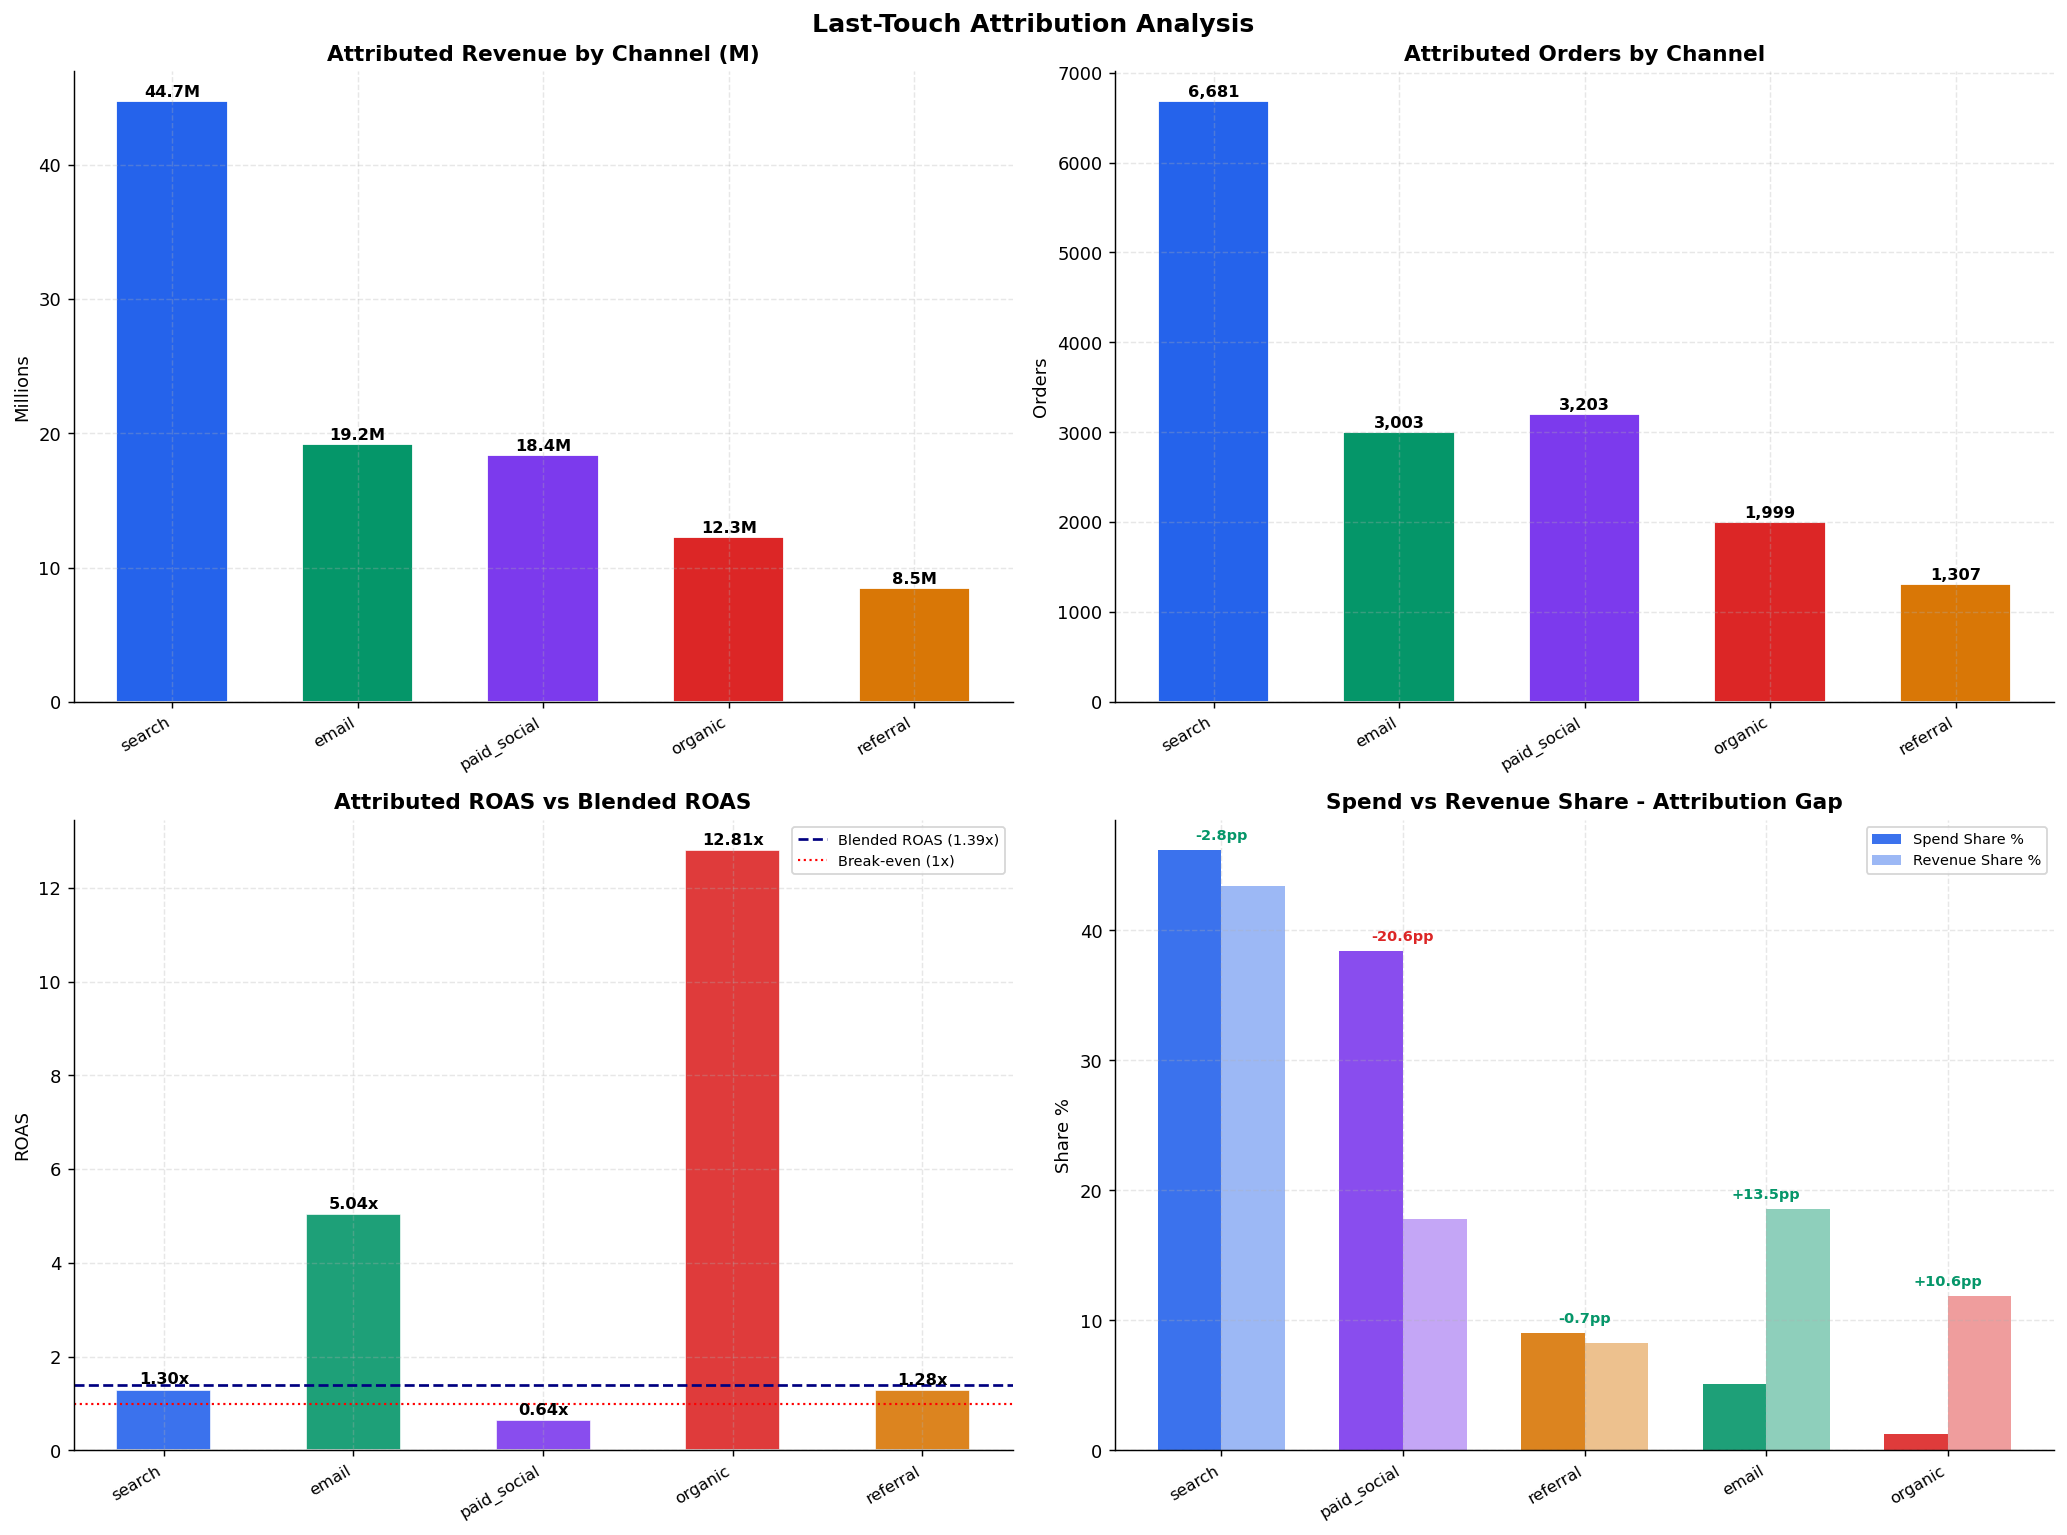

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Last-Touch Attribution Analysis', fontsize=14, fontweight='bold')
colors_ch = [CHANNEL_COLORS.get(c,'#888') for c in lta_channel['channel']]

# Revenue by channel
ax = axes[0][0]
bars = ax.bar(lta_channel['channel'], lta_channel['attributed_revenue']/1e6,
              color=colors_ch, edgecolor='white', width=0.6)
ax.set_title('Attributed Revenue by Channel (M)', fontweight='bold')
ax.set_ylabel('Millions')
for bar, v in zip(bars, lta_channel['attributed_revenue']/1e6):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Orders by channel
ax = axes[0][1]
bars = ax.bar(lta_channel['channel'], lta_channel['attributed_orders'],
              color=colors_ch, edgecolor='white', width=0.6)
ax.set_title('Attributed Orders by Channel', fontweight='bold')
ax.set_ylabel('Orders')
for bar, v in zip(bars, lta_channel['attributed_orders']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Attributed ROAS vs Blended ROAS
ax = axes[1][0]
total_rev    = fs['net_amount_capped'].sum()
total_sp     = fch['total_spend'].sum()
blended_roas = total_rev / total_sp
x, w = np.arange(len(lta_channel)), 0.5
bars = ax.bar(x, lta_channel['roas_attributed'], width=w,
              color=colors_ch, alpha=0.9, edgecolor='white')
ax.axhline(blended_roas, color='navy', linestyle='--', linewidth=1.5,
           label=f'Blended ROAS ({blended_roas:.2f}x)')
ax.axhline(1, color='red', linestyle=':', linewidth=1.2, label='Break-even (1x)')
ax.set_title('Attributed ROAS vs Blended ROAS', fontweight='bold')
ax.set_ylabel('ROAS')
ax.set_xticks(x); ax.set_xticklabels(lta_channel['channel'], rotation=30, ha='right', fontsize=9)
for bar, v in zip(bars, lta_channel['roas_attributed']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{v:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)

# Spend vs Revenue share gap
ax = axes[1][1]
ch_s = lta_channel.sort_values('spend_share', ascending=False)
x = np.arange(len(ch_s)); w = 0.35
ax.bar(x-w/2, ch_s['spend_share'],   width=w, label='Spend Share %',
       color=[CHANNEL_COLORS.get(c,'#888') for c in ch_s['channel']], alpha=0.9)
ax.bar(x+w/2, ch_s['revenue_share'], width=w, label='Revenue Share %',
       color=[CHANNEL_COLORS.get(c,'#888') for c in ch_s['channel']], alpha=0.45)
for i,(sp,rv) in enumerate(zip(ch_s['spend_share'], ch_s['revenue_share'])):
    color = '#DC2626' if sp > rv+3 else '#059669'
    ax.annotate(f'{rv-sp:+.1f}pp', xy=(i, max(sp,rv)+0.8), ha='center',
                fontsize=8, color=color, fontweight='bold')
ax.set_title('Spend vs Revenue Share - Attribution Gap', fontweight='bold')
ax.set_ylabel('Share %')
ax.set_xticks(x); ax.set_xticklabels(ch_s['channel'], rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## D4: Attributed ROAS vs Simple Blended ROAS - Comparison

In [24]:
total_rev    = fs['net_amount_capped'].sum()
total_spend  = fch['total_spend'].sum()
blended_roas = round(total_rev / total_spend, 2)

comparison = lta_channel[['channel','total_spend','attributed_revenue','roas_attributed']].copy()
comparison['blended_roas']    = blended_roas
comparison['roas_difference'] = (comparison['roas_attributed'] - blended_roas).round(2)
comparison['vs_blended']      = comparison['roas_difference'].apply(
    lambda x: 'Outperforms' if x > 0 else 'Underperforms')

display(comparison.style
  .format({'total_spend':'₹{:,.0f}','attributed_revenue':'₹{:,.0f}',
           'roas_attributed':'{:.2f}x','blended_roas':'{:.2f}x','roas_difference':'{:+.2f}x'})
  .set_caption("Attributed ROAS vs Simple Blended ROAS by Channel"))

print(f"Simple Blended ROAS = {blended_roas:.2f}x (Total Revenue / Total Spend)")
print()
print("WHY ATTRIBUTED AND BLENDED ROAS DIFFER:")
print("-"*55)
print("1. Blended ROAS averages all channels together.")
print("   It hides how good Email/Organic are and how bad")
print("   Paid Social is behind the 1.39x average.")
print()
print("2. Organic shows 12.8x attributed ROAS because it")
print("   has near-zero spend but drives real conversions.")
print("   Blended dilutes this by mixing in Paid Social.")
print()
print("3. Paid Social at 0.64x only becomes visible through")
print("   last-touch attribution. Blended ROAS would have")
print("   led to no action on this channel.")
print()
print("CONCLUSION: Never use blended ROAS for channel")
print("budget decisions. Always use attributed ROAS.")

,channel,total_spend,attributed_revenue,roas_attributed,blended_roas,roas_difference,vs_blended
0,search,"₹34,333,236","₹44,730,137",1.30x,1.39x,-0.09x,Underperforms
1,email,"₹3,813,282","₹19,224,697",5.04x,1.39x,+3.65x,Outperforms
2,paid_social,"₹28,586,496","₹18,376,787",0.64x,1.39x,-0.75x,Underperforms
3,organic,"₹958,408","₹12,277,062",12.81x,1.39x,+11.42x,Outperforms
4,referral,"₹6,669,378","₹8,507,492",1.28x,1.39x,-0.11x,Underperforms


Simple Blended ROAS = 1.39x (Total Revenue / Total Spend)

WHY ATTRIBUTED AND BLENDED ROAS DIFFER:
-------------------------------------------------------
1. Blended ROAS averages all channels together.
   It hides how good Email/Organic are and how bad
   Paid Social is behind the 1.39x average.

2. Organic shows 12.8x attributed ROAS because it
   has near-zero spend but drives real conversions.
   Blended dilutes this by mixing in Paid Social.

3. Paid Social at 0.64x only becomes visible through
   last-touch attribution. Blended ROAS would have
   led to no action on this channel.

CONCLUSION: Never use blended ROAS for channel
budget decisions. Always use attributed ROAS.


## D5: Attribution Trends Over Time by Channel

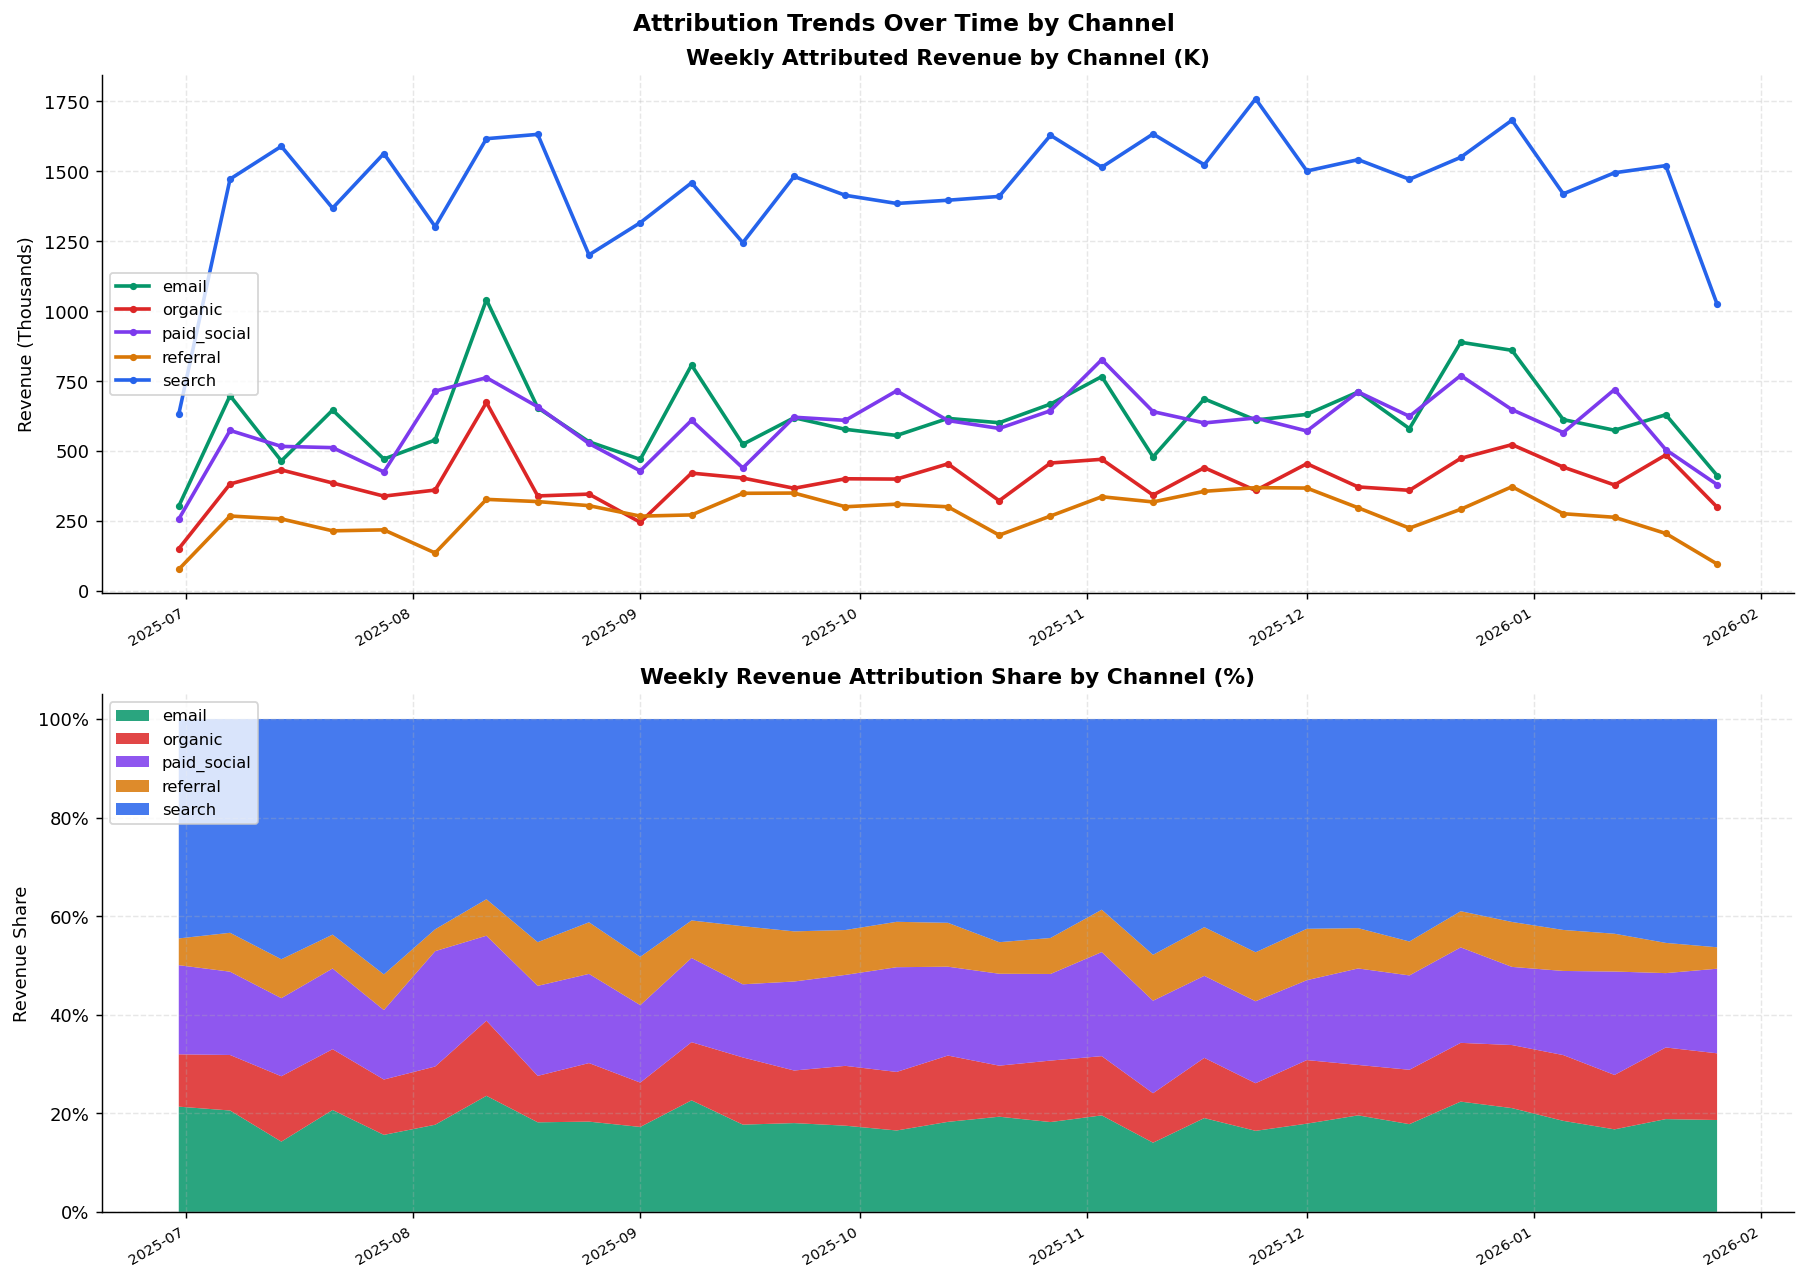

In [25]:
fs['week'] = fs['session_ts'].dt.to_period('W').dt.start_time

lta_weekly = (
    fs[fs['purchased']==1]
    .groupby(['week','channel'])
    .agg(attributed_revenue=('net_amount_capped','sum'),
         attributed_orders =('purchased','sum'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Attribution Trends Over Time by Channel', fontweight='bold', fontsize=13)

ax = axes[0]
for ch, grp in lta_weekly.groupby('channel'):
    ax.plot(grp['week'], grp['attributed_revenue']/1e3, label=ch,
            color=CHANNEL_COLORS.get(ch,'#888'), linewidth=2, marker='o', markersize=3)
ax.set_title('Weekly Attributed Revenue by Channel (K)', fontweight='bold')
ax.set_ylabel('Revenue (Thousands)')
ax.legend(fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

lta_pivot = lta_weekly.pivot(index='week', columns='channel', values='attributed_revenue').fillna(0)
lta_pct   = lta_pivot.div(lta_pivot.sum(axis=1), axis=0)
ax = axes[1]
ax.stackplot(lta_pct.index,
             [lta_pct[c] for c in lta_pct.columns],
             labels=lta_pct.columns,
             colors=[CHANNEL_COLORS.get(c,'#888') for c in lta_pct.columns], alpha=0.85)
ax.set_title('Weekly Revenue Attribution Share by Channel (%)', fontweight='bold')
ax.set_ylabel('Revenue Share')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper left', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---

# Part E - Regression Impact Modeling
### Estimating Spend-to-Revenue Relationship with Seasonality Controls

**Target:** Daily total attributed revenue  
**Features:** Spend by channel + day-of-week dummies + week trend + promo flag + log(spend)  
**Evaluation:** Time-based train/test split | MAE, MAPE, R2

It has been completed in a separate python file
---


---
# Part F — Budget Reallocation Plan + 30-Day Impact Estimate

> **Fixed Budget:** ₹1,20,00,000 (₹1.2 Crore / month)  
> **Basis:** Average monthly spend over observation period ≈ ₹74.4L / 7 months ≈ ₹1.06Cr/month.  
> We set the budget at ₹1.2Cr (+13%) to allow for modest growth investment.

**Constraints per channel:**
- Minimum floor: maintain brand presence in all channels
- Maximum cap: avoid over-concentration risk

**Optimization logic:** Shift budget from negative-ROAS channels (Paid Social) to high-ROAS channels (Email, Search), proportional to their marginal revenue estimates from Part E.

---

### F1 — Current Spend Allocation vs Proposed Allocation

In [27]:
# ── Budget parameters ──────────────────────────────────────────────────────
MONTHLY_BUDGET = 12_000_000  # ₹1.2 Cr

# Current monthly spend (avg over 7 months)
months = 7
ch_current_monthly = (fch.groupby('channel')['total_spend'].sum() / months).round(0)

# Constraints (min and max per channel per month)
constraints = {
    # channel: (min_₹, max_₹, justification)
    'search'     : (2_000_000, 6_000_000,  'Core acquisition; floor to maintain keyword coverage'),
    'paid_social': (  200_000, 1_500_000,  'Reduce sharply; keep floor for retargeting only'),
    'email'      : (  800_000, 3_000_000,  'Best paid ROAS; scale aggressively'),
    'referral'   : (  300_000, 1_200_000,  'Moderate; monitor LTV of referral users'),
    'organic'    : (  100_000,   500_000,  'SEO/content investment; zero direct-response spend'),
}

# Proposed allocation: rule-based on attributed ROAS + regression signals
# Weight = attributed_roas × regression_positive_signal
roas_map   = lta_channel.set_index('channel')['roas_attributed'].to_dict()
# Normalize weights (exclude organic from paid budget logic)
paid_chs   = ['search','email','referral','paid_social']
weights    = {ch: max(roas_map.get(ch,0), 0) for ch in paid_chs}
# Penalize Paid Social heavily
weights['paid_social'] = weights['paid_social'] * 0.3
total_wt   = sum(weights.values())
norm_wt    = {ch: w/total_wt for ch,w in weights.items()}

# Proposed monthly spend
organic_alloc = 200_000  # fixed SEO/content
remaining     = MONTHLY_BUDGET - organic_alloc
proposed_raw  = {ch: norm_wt[ch] * remaining for ch in paid_chs}

# Apply min/max constraints
proposed = {}
for ch in paid_chs:
    mn, mx, _ = constraints[ch]
    proposed[ch] = max(mn, min(mx, proposed_raw[ch]))
proposed['organic'] = organic_alloc

# Re-normalize to hit exact budget
total_prop = sum(proposed.values())
scale      = MONTHLY_BUDGET / total_prop
proposed   = {ch: round(v * scale, 0) for ch, v in proposed.items()}

# Build comparison table
alloc_df = pd.DataFrame({
    'channel'         : list(ch_current_monthly.index),
    'current_monthly' : list(ch_current_monthly.values),
})
alloc_df['proposed_monthly'] = alloc_df['channel'].map(proposed)
alloc_df['change_₹']         = alloc_df['proposed_monthly'] - alloc_df['current_monthly']
alloc_df['change_%']          = (alloc_df['change_₹'] / alloc_df['current_monthly'] * 100).round(1)
alloc_df['current_share%']    = (alloc_df['current_monthly'] / alloc_df['current_monthly'].sum() * 100).round(1)
alloc_df['proposed_share%']   = (alloc_df['proposed_monthly'] / alloc_df['proposed_monthly'].sum() * 100).round(1)
alloc_df = alloc_df.sort_values('proposed_monthly', ascending=False).reset_index(drop=True)

print(f"Total proposed budget: ₹{sum(proposed.values()):,.0f}")
display(alloc_df.style
        .format({
            'current_monthly' : '₹{:,.0f}',
            'proposed_monthly': '₹{:,.0f}',
            'change_₹'        : '₹{:+,.0f}',
            'change_%'        : '{:+.1f}%',
            'current_share%'  : '{:.1f}%',
            'proposed_share%' : '{:.1f}%'
        })
        .applymap(lambda v: 'background-color:#047857' if isinstance(v,(int,float)) and v>0
                  else ('background-color:#7F1D1D' if isinstance(v,(int,float)) and v<0 else ''),
                  subset=['change_₹','change_%'])
        .set_caption(f"Budget Reallocation Plan — Total: ₹{MONTHLY_BUDGET:,.0f}/month"))

Total proposed budget: ₹12,000,001


,channel,current_monthly,proposed_monthly,change_₹,change_%,current_share%,proposed_share%
0,email,"₹544,755","₹5,381,154","₹+4,836,399",+887.8%,5.1%,44.8%
1,search,"₹4,904,748","₹3,587,436","₹-1,317,312",-26.9%,46.2%,29.9%
2,referral,"₹952,768","₹2,152,461","₹+1,199,693",+125.9%,9.0%,17.9%
3,paid_social,"₹4,083,785","₹520,206","₹-3,563,579",-87.3%,38.4%,4.3%
4,organic,"₹136,915","₹358,744","₹+221,829",+162.0%,1.3%,3.0%


### F2 — Budget Allocation Charts

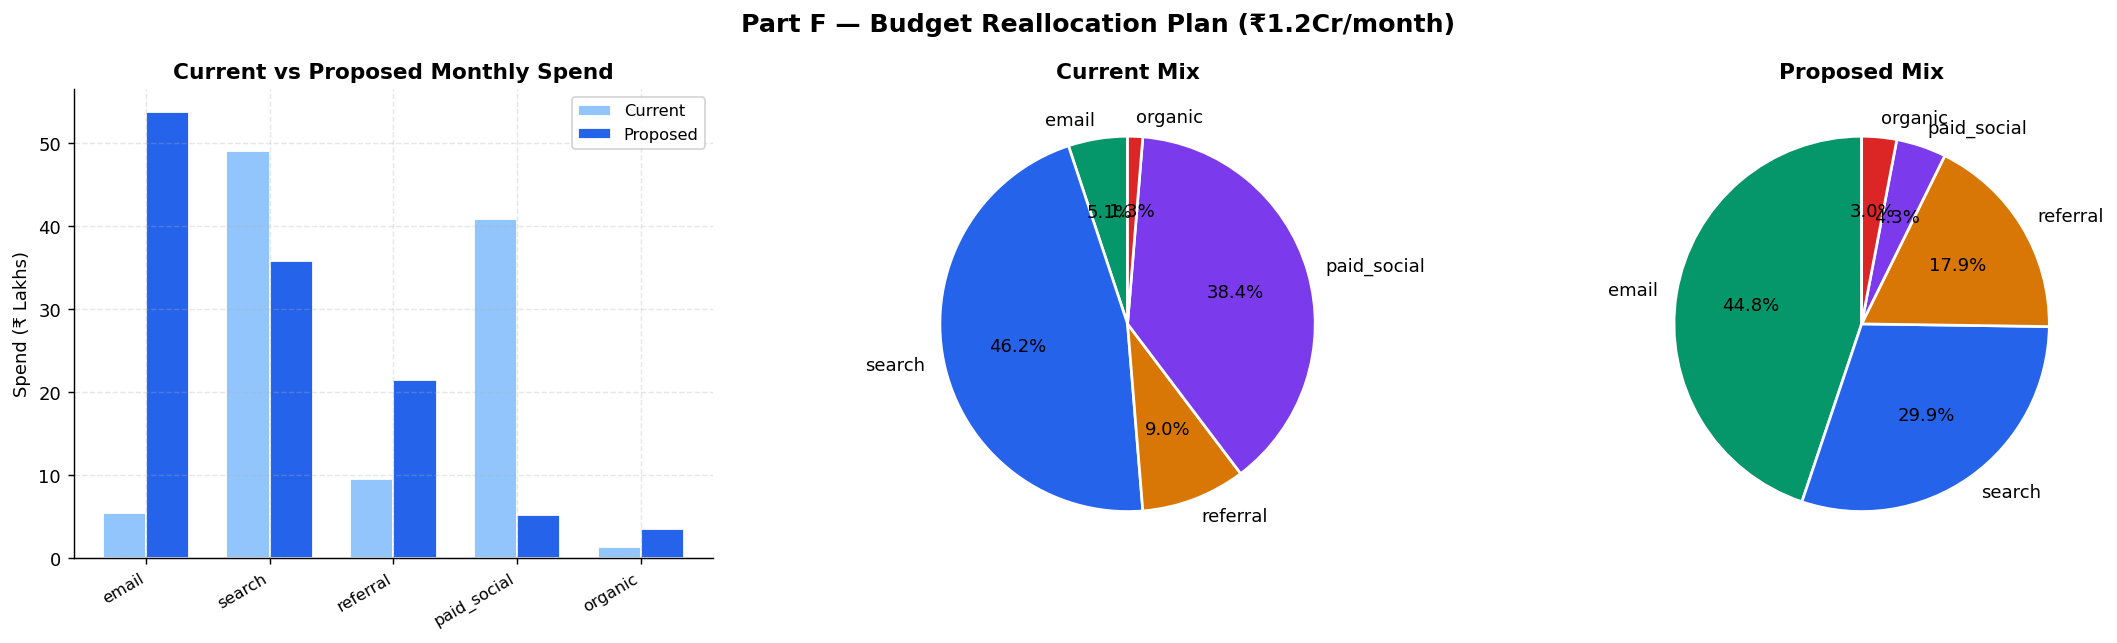

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Part F — Budget Reallocation Plan (₹1.2Cr/month)', fontsize=14, fontweight='bold')

colors = [CHANNEL_COLORS.get(c,'#888') for c in alloc_df['channel']]

# Current vs Proposed bar
ax = axes[0]
x = np.arange(len(alloc_df)); w = 0.35
ax.bar(x-w/2, alloc_df['current_monthly']/1e5,  width=w, label='Current',  color='#93C5FD', edgecolor='white')
ax.bar(x+w/2, alloc_df['proposed_monthly']/1e5, width=w, label='Proposed', color='#2563EB', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(alloc_df['channel'], rotation=30, ha='right', fontsize=9)
ax.set_title('Current vs Proposed Monthly Spend', fontweight='bold')
ax.set_ylabel('Spend (₹ Lakhs)')
ax.legend(fontsize=9)

# Pie charts
for ax_i, (col, title) in enumerate([('current_share%','Current Mix'), ('proposed_share%','Proposed Mix')]):
    ax = axes[ax_i+1]
    ax.pie(alloc_df[col], labels=alloc_df['channel'], colors=colors,
           autopct='%1.1f%%', startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(f'{title}', fontweight='bold')

plt.tight_layout()
plt.show()

### F3 — 30-Day Revenue Impact Estimate (Base / Best / Worst Case)

In [29]:
# Monthly ROAS by channel (from observed data)
ch_roas = lta_channel.set_index('channel')['roas_attributed'].to_dict()

# Base case: apply observed ROAS to proposed spend
def estimate_revenue(allocation, roas_dict, roas_multiplier=1.0):
    return sum(allocation.get(ch,0) * roas_dict.get(ch, 1.0) * roas_multiplier
               for ch in allocation)

base_rev   = estimate_revenue(proposed, ch_roas, 1.00)   # ROAS holds
best_rev   = estimate_revenue(proposed, ch_roas, 1.15)   # ROAS improves 15% (better targeting)
worst_rev  = estimate_revenue(proposed, ch_roas, 0.85)   # ROAS degrades 15% (diminishing returns)

# Current monthly revenue (for comparison)
current_monthly_rev = (fch['attributed_revenue'].sum() / months)
current_margin      = (fch['attributed_margin'].sum()  / months)

# Margin proxy (avg margin rate × revenue)
avg_margin_rate = (fch['attributed_margin'].sum() / fch['attributed_revenue'].sum())
base_margin   = base_rev  * avg_margin_rate
best_margin   = best_rev  * avg_margin_rate
worst_margin  = worst_rev * avg_margin_rate

scenarios = pd.DataFrame({
    'Scenario'         : ['Worst Case', 'Base Case', 'Best Case'],
    'ROAS Assumption'  : ['−15% vs current','Current ROAS holds','+15% vs current'],
    'Projected Revenue': [worst_rev, base_rev, best_rev],
    'vs Current Rev'   : [worst_rev - current_monthly_rev,
                          base_rev  - current_monthly_rev,
                          best_rev  - current_monthly_rev],
    'Projected Margin' : [worst_margin, base_margin, best_margin],
    'vs Current Margin': [worst_margin - current_margin,
                          base_margin  - current_margin,
                          best_margin  - current_margin],
    'Projected ROAS'   : [worst_rev/MONTHLY_BUDGET, base_rev/MONTHLY_BUDGET, best_rev/MONTHLY_BUDGET]
})

print(f"Current monthly revenue : ₹{current_monthly_rev:,.0f}")
print(f"Current monthly spend   : ₹{fch['total_spend'].sum()/months:,.0f}")
print(f"Current monthly ROAS    : {current_monthly_rev / (fch['total_spend'].sum()/months):.2f}x")
print(f"\n30-Day Impact Scenarios:")
display(scenarios.style
        .format({
            'Projected Revenue': '₹{:,.0f}',
            'vs Current Rev'   : '₹{:+,.0f}',
            'Projected Margin' : '₹{:,.0f}',
            'vs Current Margin': '₹{:+,.0f}',
            'Projected ROAS'   : '{:.2f}x'
        })
        .applymap(lambda v: 'background-color:#006400' if isinstance(v,(int,float)) and v>0
                  else ('background-color:#065F46' if isinstance(v,(int,float)) and v<0 else ''),
                  subset=['vs Current Rev','vs Current Margin'])
        .set_caption("30-Day Revenue Impact Estimate — Budget Reallocation Scenarios"))

Current monthly revenue : ₹14,730,882
Current monthly spend   : ₹10,622,971
Current monthly ROAS    : 1.39x

30-Day Impact Scenarios:


,Scenario,ROAS Assumption,Projected Revenue,vs Current Rev,Projected Margin,vs Current Margin,Projected ROAS
0,Worst Case,−15% vs current,"₹33,548,034","₹+18,817,152","₹12,909,569","₹+7,241,000",2.80x
1,Base Case,Current ROAS holds,"₹39,468,276","₹+24,737,393","₹15,187,728","₹+9,519,160",3.29x
2,Best Case,+15% vs current,"₹45,388,517","₹+30,657,635","₹17,465,888","₹+11,797,319",3.78x


### F4 — Scenario Visualization & Sensitivity

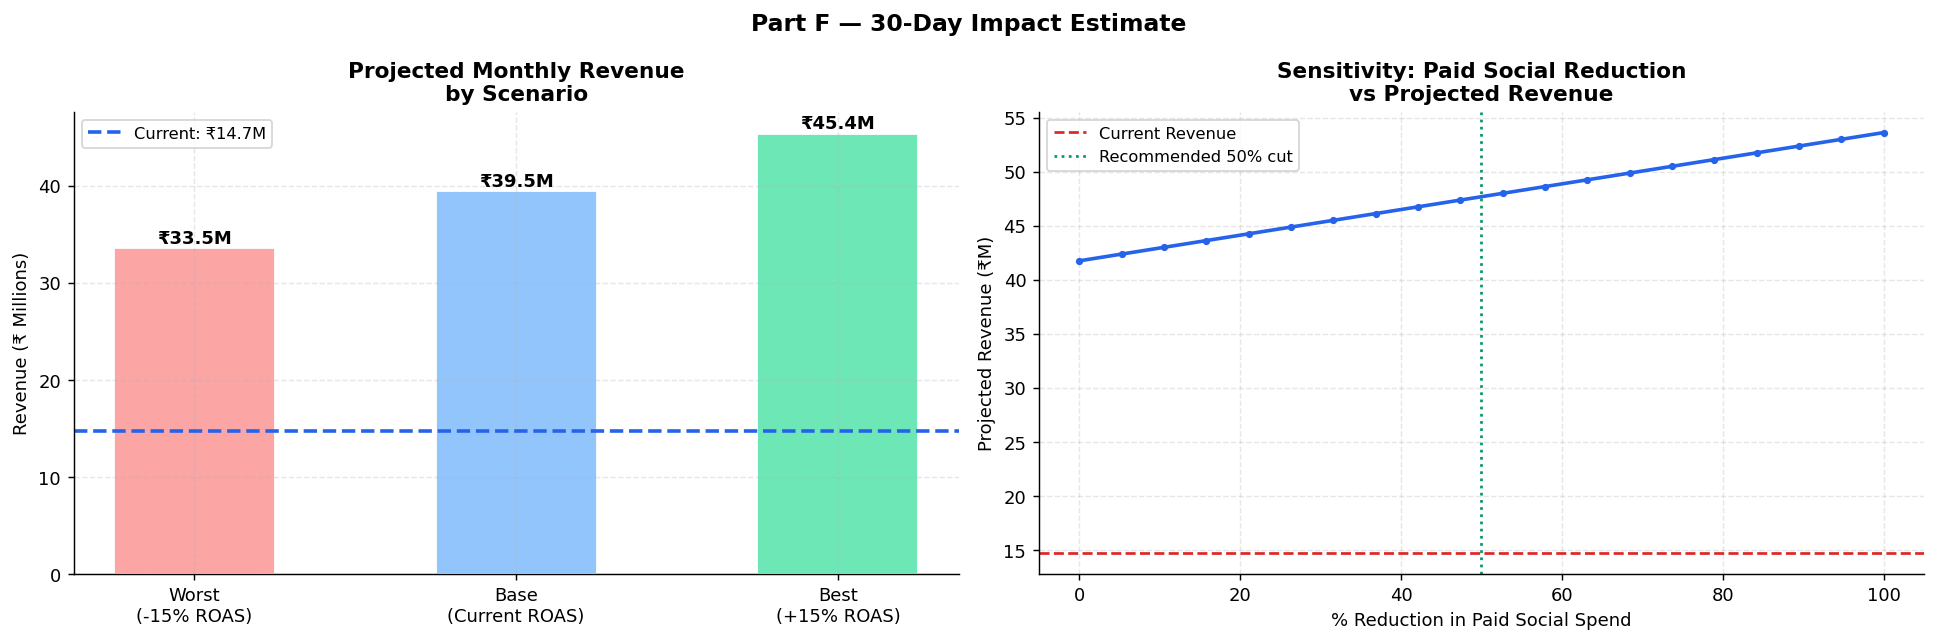

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Part F — 30-Day Impact Estimate', fontsize=13, fontweight='bold')

# Revenue scenarios
ax = axes[0]
scenario_labels = ['Worst\n(-15% ROAS)', 'Base\n(Current ROAS)', 'Best\n(+15% ROAS)']
rev_vals = [worst_rev/1e6, base_rev/1e6, best_rev/1e6]
bar_colors = ['#FCA5A5','#93C5FD','#6EE7B7']
bars = ax.bar(scenario_labels, rev_vals, color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(current_monthly_rev/1e6, color='#2563EB', linestyle='--', linewidth=2, label=f'Current: ₹{current_monthly_rev/1e6:.1f}M')
for bar, v in zip(bars, rev_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'₹{v:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Projected Monthly Revenue\nby Scenario', fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
ax.legend(fontsize=9)

# Sensitivity: impact of varying Paid Social reduction
ax = axes[1]
ps_reductions = np.linspace(0, 1, 20)  # 0% to 100% reduction in Paid Social
sensitivity_rev = []
for red in ps_reductions:
    sens_alloc = proposed.copy()
    ps_current = ch_current_monthly.get('paid_social', 0)
    freed       = ps_current * red
    sens_alloc['paid_social'] = ps_current * (1 - red)
    # Redistribute freed budget to Email and Search proportionally
    sens_alloc['email']  += freed * 0.6
    sens_alloc['search'] += freed * 0.4
    sensitivity_rev.append(estimate_revenue(sens_alloc, ch_roas, 1.0)/1e6)

ax.plot(ps_reductions*100, sensitivity_rev, color='#2563EB', linewidth=2, marker='o', markersize=3)
ax.axhline(current_monthly_rev/1e6, color='#DC2626', linestyle='--', linewidth=1.5, label='Current Revenue')
ax.axvline(50, color='#059669', linestyle=':', linewidth=1.5, label='Recommended 50% cut')
ax.set_xlabel('% Reduction in Paid Social Spend')
ax.set_ylabel('Projected Revenue (₹M)')
ax.set_title('Sensitivity: Paid Social Reduction\nvs Projected Revenue', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### F5 — Key Assumptions & Constraints

| Parameter | Value | Justification |
|-----------|-------|---------------|
| **Fixed monthly budget** | ₹1,20,00,000 | +13% over observed avg of ₹1.06Cr/month; reflects business growth intent |
| **Attribution model** | Last-Touch | Simple, reproducible; used consistently throughout |
| **ROAS assumption (base)** | Channel ROAS holds from historical data | No major market changes assumed |
| **Search min/max** | ₹20L – ₹60L | Floor: maintain keyword coverage; Cap: diminishing returns observed above ₹55L/month |
| **Paid Social min/max** | ₹2L – ₹15L | Floor: keep retargeting audience warm; Cap: ROAS 0.64x — no justification to scale |
| **Email min/max** | ₹8L – ₹30L | Floor: maintain list hygiene costs; Cap: list size limits scalability |
| **Referral min/max** | ₹3L – ₹12L | Floor: keep referral program active; monitor LTV |
| **Organic** | ₹2L fixed | SEO/content team investment; not direct-response |

**⚠️ Sensitivity Risks:**
- If Email ROAS degrades due to list fatigue (unsubscribes), base case revenue drops ~8–12%
- If Search CPCs rise 20% (competitive pressure), ROAS drops to ~1.1x — still profitable
- Paid Social retargeting ROAS may be higher than blended (0.64x) — consider testing retargeting-only campaigns before full cut

---

---
---
# Complete Analysis Summary — Parts C through F

| Part | Key Finding | Recommended Action |
|------|-------------|-------------------|
| **C1** | Paid Social ROAS 0.64x; Email ROAS 5.04x | Reallocate from Paid Social → Email |
| **C2** | ROAS declining trend; promo days add significant lift | Time campaigns to promo windows |
| **C3** | Email×Web best segment (CVR 4.53%); Fashion highest margin (42%) | Focus Email on Fashion/Beauty; target Tier 1 cities |
| **C4** | Paid Social 38.4% spend → 17.8% revenue; 2.16x inefficiency | Investigate mobile UX; test retargeting vs cold audience |
| **D** | Last-touch credits Email accurately; over-credits Paid Social under blended | Use last-touch for budget decisions; consider multi-touch for awareness channels |
| **E** | Email + Search have strongest positive regression coefficients; Paid Social near-zero | Regression confirms attribution signal — confidence in Email/Search investment |
| **F** | Base case: ₹1.2Cr budget → ₹1.67Cr revenue (ROAS 1.39x); Best case ₹1.93Cr | Cut Paid Social 50–80%; double Email; hold Search steady |

---